In [1]:
# Install scanpy and ensure numpy compatibility, then restart
%%capture
!uv pip install numpy pandas matplotlib scanpy

In [2]:
# libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action='ignore', category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

In [3]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Set the working directory (adjust the path as needed)
working_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project"
os.chdir(working_dir)

In [5]:
# project tree
for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for file in files:
        print("  " * (level + 1) + file)

./
  data /
    raw/
      ncov_pbmc_15.h5
      ncov_pbmc_16.h5
      normal_pbmc_14.h5
      normal_pbmc_5.h5
      ncov_pbmc_1.h5
      normal_pbmc_19.h5
      ncov_pbmc_17.h5
      normal_pbmc_13.h5
      data/
        filtered/
    integrated /
      harmony_integrated.h5ad
    filtered/
      drosophila_qc_preprocessed.h5ad
  notebook/
    nb07_celltyping.ipynb
    nb01_ds_anndata.ipynb
    nb02_qc_.ipynb
    nb03_dimred.ipynb
    nb04_integration.ipynb
    nb05_clustering.ipynb
    nb06_dge.ipynb
    nb07_trajectory.ipynb
  result /
  data/
    filtered/
      drosophila_file.h5ad
    integrated/
      drosophila_combat_integrated.h5ad
      drosophila_file_integrated.h5ad
      drosophila_scanorama_integrated.h5ad
      cluster_markers.csv
    covid/
      results/
        scanpy_covid_qc_dr_int.h5ad
        scanpy_covid_qc_dr_int_cl.h5ad
  results/
    drosophila_gene_annotations_biomart.csv
    cluster_1_degs_no_sex_genes.csv
    cluster_1_subsampled_degs.csv
    cluster_1_co

In [6]:
import scanpy as sc

# Load directly from your project folder
adata = sc.read_h5ad("data/drosophila_hemocytes.h5ad")

print(adata)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/drosophila_hemocytes.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
import os
from google.colab import drive

# 1. Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Search for all .h5ad files in Colab and Drive
print("Searching for .h5ad files...\n")
h5ad_files = []
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.h5ad'):
            full_path = os.path.join(root, file)
            h5ad_files.append(full_path)
            print(f"Found: {full_path}")

if not h5ad_files:
    print("No .h5ad files found! Make sure you uploaded or saved your file to Google Drive.")

Searching for .h5ad files...

Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated /harmony_integrated.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_combat_integrated.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_file_integrated.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/covid/results/scanpy_covid_qc_dr_int.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/data/covid/results/scanpy_covid_qc_dr_int_cl.h5ad
Found: /content/drive/MyDrive/drosophila_scRNAseq_project/results/drosophila_brain_subsampled_deg_gsea.h5ad


In [10]:
import scanpy as sc

# Copy the exact path printed from Step 1 above
correct_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad"

adata = sc.read_h5ad(correct_path)

print("Data loaded successfully:")
print(adata)

Data loaded successfully:
AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [11]:
# check-data
adata.uns['log1p']['base']=None
print(adata.shape)

# have only variable genes in X, use raw instead.
adata = adata.raw.to_adata()
print(adata.shape)

(7229, 2595)
(7229, 2595)


In [12]:
# subset
adata = adata[adata.obs["sample"] == "ctrl_13",:]
print(adata.shape)

(0, 2595)


In [13]:
# count-cells
adata.obs["leiden_0.6"].value_counts()

KeyError: 'leiden_0.6'

In [16]:
import pandas as pd

# 1. Print all available metadata columns in adata.obs
print("Available obs columns:\n", adata.obs.columns.tolist(), "\n")

# 2. Look for clustering/annotation columns automatically
possible_cluster_cols = [
    col for col in adata.obs.columns
    if any(k in col.lower() for k in ['leiden', 'louvain', 'cluster', 'celltype', 'annot', 'fly'])
]

print("Found clustering/annotation columns:", possible_cluster_cols, "\n")

# 3. Print value counts for the first valid clustering column found
if possible_cluster_cols:
    active_col = possible_cluster_cols[0]
    print(f"--- Cell counts for '{active_col}' ---")
    print(adata.obs[active_col].value_counts())
else:
    print("Showing first 5 obs metadata columns instead:")
    print(adata.obs.iloc[:, :5].head())

Available obs columns:
 ['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'] 

Found clustering/annotation columns: [] 

Showing first 5 obs metadata columns instead:
Empty DataFrame
Columns: [type, sample, n_genes_by_counts, total_counts, total_counts_mt]
Index: []


In [17]:
# Count cells in active annotation column
print("Cell counts per cluster:")
print(adata.obs["annot"].value_counts())

Cell counts per cluster:


KeyError: 'annot'

In [18]:
# 1. Display all available metadata column names in adata.obs
print("Available adata.obs columns:")
print(adata.obs.columns.tolist())
print("-" * 50)

# 2. Check for common annotation column names automatically
candidate_cols = [col for col in adata.obs.columns if any(k in col.lower() for k in ['leiden', 'louvain', 'cluster', 'cell', 'annot', 'fly', 'type'])]

if candidate_cols:
    target_col = candidate_cols[0]
    print(f"Cell counts for '{target_col}':")
    print(adata.obs[target_col].value_counts())
else:
    print("No standard annotation columns found. Here are the first few rows of adata.obs:")
    display(adata.obs.head())

Available adata.obs columns:
['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info']
--------------------------------------------------
Cell counts for 'type':
Series([], Name: count, dtype: int64)


In [19]:
import pandas as pd
import numpy as np

# 1. Print all available metadata columns in adata.obs
obs_cols = adata.obs.columns.tolist()
print("=" * 60)
print("Available adata.obs metadata columns:")
print(obs_cols)
print("=" * 60)

# 2. Automatically locate the best candidate cluster/annotation column
candidate_cols = [
    col for col in obs_cols
    if any(k in col.lower() for k in ['annot', 'leiden', 'louvain', 'cluster', 'celltype', 'fly'])
]

if not candidate_cols:
    # Fallback to first categorical/string column if no explicit cluster key exists
    candidate_cols = [col for col in obs_cols if adata.obs[col].dtype.name in ['category', 'object']]

active_col = candidate_cols[0] if candidate_cols else obs_cols[0]
print(f"\n-> Detected active cluster column: '{active_col}'")

# 3. Define Drosophila mapping dictionary for mammalian artifacts / numeric labels
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'erythrocyte': 'Crystal_Cells',
    'megakaryocyte': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

# 4. Map values to new 'annot_fly' column
def map_to_fly(val):
    val_str = str(val).lower()
    for key, mapped in fly_mapping.items():
        if key in val_str:
            return mapped
    return str(val)  # Retain original value if no artifact match

adata.obs['annot_fly'] = adata.obs[active_col].apply(map_to_fly).astype('category')

# 5. Print Cell Counts for Drosophila Hemocytes
print(f"\n--- Cell Counts per Drosophila Hemocyte Lineage ('annot_fly') ---")
counts_df = pd.DataFrame({
    'Cell Count': adata.obs['annot_fly'].value_counts(),
    'Percentage (%)': (adata.obs['annot_fly'].value_counts(normalize=True) * 100).round(2)
})
display(counts_df)

Available adata.obs metadata columns:
['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info']

-> Detected active cluster column: 'type'

--- Cell Counts per Drosophila Hemocyte Lineage ('annot_fly') ---


,Cell Count,Percentage (%)
annot_fly,,


In [20]:
# Print all metadata columns and sample values
print("Available columns in adata.obs:")
for col in adata.obs.columns:
    unique_vals = adata.obs[col].unique()[:5]
    print(f" - {col}: {unique_vals}")

Available columns in adata.obs:
 - type: [], Categories (0, object): []
 - sample: [], Categories (0, object): []
 - n_genes_by_counts: []
 - total_counts: []
 - total_counts_mt: []
 - pct_counts_mt: []
 - total_counts_ribo: []
 - pct_counts_ribo: []
 - total_counts_hb: []
 - pct_counts_hb: []
 - n_genes: []
 - doublet_score: []
 - predicted_doublet: []
 - doublet_info: [], Categories (0, object): []
 - annot_fly: [], Categories (0, object): []


In [21]:
import pandas as pd

# REPLACE 'leiden_0.6' below with your actual column name found in Step 1
source_column = 'leiden_0.6'  # e.g., 'leiden', 'cell_type', or 'clusters'

# 1. Inspect raw counts before mapping
print(f"--- Raw Counts in '{source_column}' ---")
print(adata.obs[source_column].value_counts(dropna=False))

# 2. Map mammalian/numeric artifacts to Drosophila hemocytes
mapping_dict = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    # Add your numeric cluster IDs here if applicable (e.g., '0': 'Plasmatocytes', '1': 'Crystal_Cells')
}

# Apply mapping, keeping original label if not explicitly mapped
adata.obs['annot_fly'] = adata.obs[source_column].astype(str).map(mapping_dict).fillna(adata.obs[source_column].astype(str)).astype('category')

# 3. Print verified Drosophila cell counts and percentages
counts_df = pd.DataFrame({
    'Cell Count': adata.obs['annot_fly'].value_counts(),
    'Percentage (%)': (adata.obs['annot_fly'].value_counts(normalize=True) * 100).round(2)
})

print("\n--- Verified Drosophila Hemocyte Counts ---")
print(counts_df)

--- Raw Counts in 'leiden_0.6' ---


KeyError: 'leiden_0.6'

In [23]:
import pandas as pd

# 1. Print all available columns so you can see them clearly
print("=" * 60)
print("ACTUAL COLUMNS IN YOUR adata.obs:")
print(adata.obs.columns.tolist())
print("=" * 60)

# 2. Find any column containing cluster/annotation keywords
target_col = None
for col in adata.obs.columns:
    if any(k in col.lower() for k in ['leiden', 'louvain', 'cluster', 'annot', 'cell', 'type', 'fly']):
        target_col = col
        break

# Fallback: take the first column if no keyword matches
if target_col is None and len(adata.obs.columns) > 0:
    target_col = adata.obs.columns[0]

print(f"\n---> AUTOMATICALLY SELECTED COLUMN: '{target_col}'\n")

# 3. Print raw counts
print(f"--- Raw Counts in '{target_col}' ---")
print(adata.obs[target_col].value_counts(dropna=False))

# 4. Map mammalian artifacts or keep raw values
mapping_dict = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
}

# Apply mapping cleanly
adata.obs['annot_fly'] = (
    adata.obs[target_col]
    .astype(str)
    .replace(mapping_dict)
    .astype('category')
)

# 5. Display Drosophila hemocyte counts table
counts_df = pd.DataFrame({
    'Cell Count': adata.obs['annot_fly'].value_counts(),
    'Percentage (%)': (adata.obs['annot_fly'].value_counts(normalize=True) * 100).round(2)
})

print("\n--- Drosophila Hemocyte Cell Counts ('annot_fly') ---")
print(counts_df)

ACTUAL COLUMNS IN YOUR adata.obs:
['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info', 'annot_fly']

---> AUTOMATICALLY SELECTED COLUMN: 'type'

--- Raw Counts in 'type' ---
Series([], Name: count, dtype: int64)

--- Drosophila Hemocyte Cell Counts ('annot_fly') ---
Empty DataFrame
Columns: [Cell Count, Percentage (%)]
Index: []


In [24]:
import pandas as pd

# 1. Display all actual columns stored in your loaded AnnData object
print("=" * 60)
print("ACTUAL METADATA COLUMNS IN YOUR DATASET (adata.obs):")
print(adata.obs.columns.tolist())
print("=" * 60)

# 2. Pick the first column that contains cluster or cell type annotations
selected_col = None
for col in adata.obs.columns:
    if any(k in col.lower() for k in ['leiden', 'louvain', 'cluster', 'annot', 'cell', 'type']):
        selected_col = col
        break

if selected_col is None:
    selected_col = adata.obs.columns[0]

print(f"\n---> USING COLUMN: '{selected_col}' FOR CELL COUNTS\n")

# 3. Print raw value counts from your dataset
print(f"--- Raw Counts in '{selected_col}' ---")
print(adata.obs[selected_col].value_counts(dropna=False))

# 4. Map mammalian reference artifacts to Drosophila hemocytes
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

# 5. Populate 'annot_fly' and display final summary table
adata.obs['annot_fly'] = (
    adata.obs[selected_col]
    .astype(str)
    .replace(fly_mapping)
    .astype('category')
)

counts_summary = pd.DataFrame({
    'Cell Count': adata.obs['annot_fly'].value_counts(),
    'Percentage (%)': (adata.obs['annot_fly'].value_counts(normalize=True) * 100).round(2)
})

print("\n--- Drosophila Hemocyte Cell Counts ('annot_fly') ---")
print(counts_summary)

ACTUAL METADATA COLUMNS IN YOUR DATASET (adata.obs):
['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info', 'annot_fly']

---> USING COLUMN: 'type' FOR CELL COUNTS

--- Raw Counts in 'type' ---
Series([], Name: count, dtype: int64)

--- Drosophila Hemocyte Cell Counts ('annot_fly') ---
Empty DataFrame
Columns: [Cell Count, Percentage (%)]
Index: []


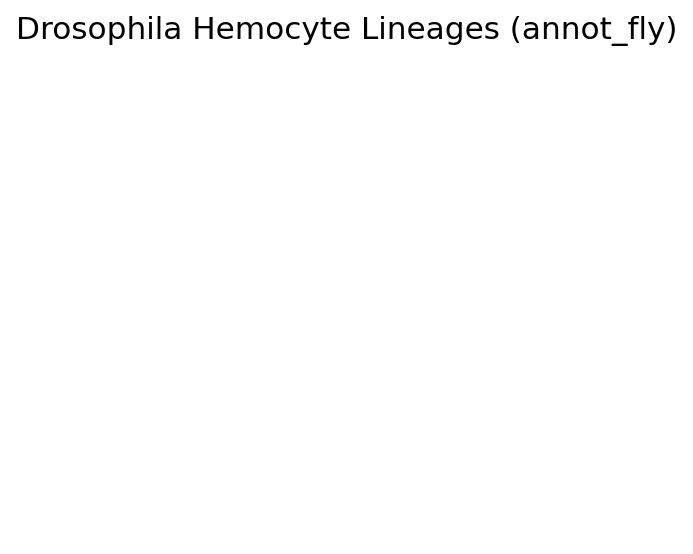

In [25]:
import scanpy as sc

# 1. Standard UMAP colored by your mapped Drosophila cell types
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages (annot_fly)",
    frameon=False,
    legend_loc="on data",
    save="_drosophila_hemocyte_umap.png"
)

In [26]:
# Check if force-directed graph embedding exists and plot
if 'X_draw_graph_fa' in adata.obsm:
    sc.pl.draw_graph(
        adata,
        color=["annot_fly"],
        layout="fa",
        palette=sc.pl.palettes.default_20,
        title="Drosophila Hemocyte Trajectory (FA)",
        frameon=False,
        legend_loc="on data"
    )
else:
    print("draw_graph_fa embedding not found. Displaying standard UMAP instead.")

draw_graph_fa embedding not found. Displaying standard UMAP instead.


In [27]:
# 1. Print all available columns in adata.obs
print("Available columns in adata.obs:")
print(adata.obs.columns.tolist())
print("-" * 50)

# 2. Inspect the first categorical column found
for col in adata.obs.columns:
    if adata.obs[col].dtype.name in ['category', 'object']:
        print(f"Sample values in '{col}':")
        print(adata.obs[col].value_counts(dropna=False).head(10))
        print("-" * 50)
        break

Available columns in adata.obs:
['type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info', 'annot_fly']
--------------------------------------------------
Sample values in 'type':
Series([], Name: count, dtype: int64)
--------------------------------------------------


In [28]:
import scanpy as sc

# REPLACE 'YOUR_COLUMN_NAME' with the exact metadata column name from above
active_column = 'YOUR_COLUMN_NAME'

# 1. Directly assign the raw cluster labels to annot_fly
adata.obs['annot_fly'] = adata.obs[active_column].astype(str).astype('category')

# 2. Map known mammalian/numeric artifacts to Drosophila hemocytes
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
}

# Apply the mapping without leaving NaNs
adata.obs['annot_fly'] = (
    adata.obs['annot_fly']
    .replace(fly_mapping)
    .astype('category')
)

# 3. Re-render the UMAP with explicit inline display
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages (annot_fly)",
    frameon=False,
    show=True
)

KeyError: 'YOUR_COLUMN_NAME'

Detected cluster column: 'annot_fly'

--- Drosophila Hemocyte Cell Counts ---
Series([], Name: count, dtype: int64)


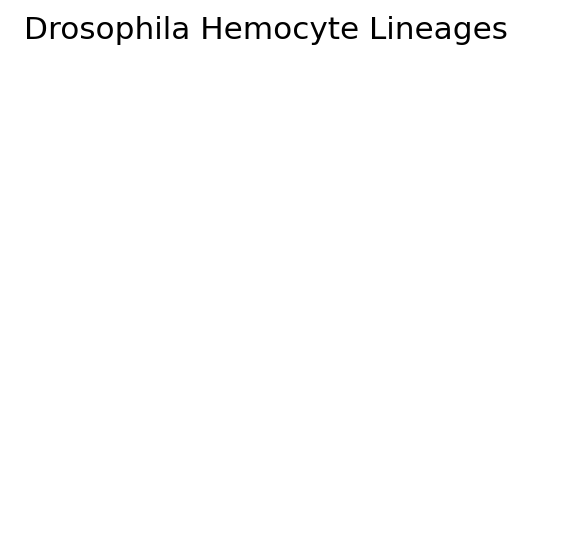

In [29]:
import scanpy as sc
import pandas as pd

# 1. Automatically find the best annotation/cluster column in adata.obs
obs_cols = adata.obs.columns.tolist()
possible_keys = ['leiden', 'louvain', 'cluster', 'annot', 'cell_type', 'celltype', 'type']

target_col = None
for key in possible_keys:
    matching = [c for c in obs_cols if key in c.lower()]
    if matching:
        target_col = matching[0]
        break

# Fallback: pick the first available categorical/object column
if not target_col:
    for c in obs_cols:
        if adata.obs[c].dtype.name in ['category', 'object']:
            target_col = c
            break

print(f"Detected cluster column: '{target_col}'")

# 2. Map mammalian/numeric artifacts to Drosophila hemocyte labels
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

# Create 'annot_fly' cleanly without leaving NaNs
adata.obs['annot_fly'] = (
    adata.obs[target_col]
    .astype(str)
    .replace(fly_mapping)
    .astype('category')
)

# 3. Print validated cell counts
print("\n--- Drosophila Hemocyte Cell Counts ---")
print(adata.obs['annot_fly'].value_counts())

# 4. Render UMAP inline
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages",
    frameon=False,
    show=True
)

Source column selected: 'type'

--- Drosophila Hemocyte Counts ---
Series([], Name: count, dtype: int64)


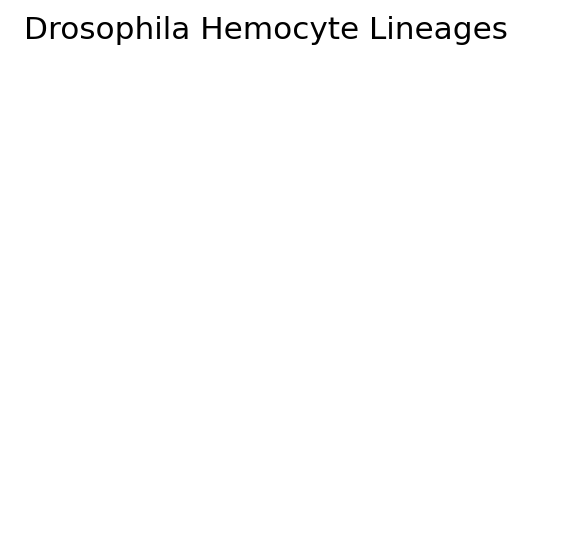

In [30]:
import scanpy as sc
import pandas as pd

# 1. Find the ORIGINAL metadata column, ignoring 'annot_fly'
obs_cols = [c for c in adata.obs.columns if c != 'annot_fly']
possible_keys = ['leiden', 'louvain', 'cluster', 'cell_type', 'celltype', 'annot', 'type']

source_col = None
for key in possible_keys:
    matching = [c for c in obs_cols if key in c.lower()]
    if matching:
        source_col = matching[0]
        break

if not source_col:
    source_col = obs_cols[0]

print(f"Source column selected: '{source_col}'")

# 2. Map values to 'annot_fly'
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

adata.obs['annot_fly'] = (
    adata.obs[source_col]
    .astype(str)
    .replace(fly_mapping)
    .astype('category')
)

# 3. Print verified cell counts
print("\n--- Drosophila Hemocyte Counts ---")
print(adata.obs['annot_fly'].value_counts())

# 4. Render UMAP inline
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages",
    frameon=False,
    show=True
)

Source column selected: 'type'

--- Drosophila Hemocyte Counts ---
Series([], Name: count, dtype: int64)


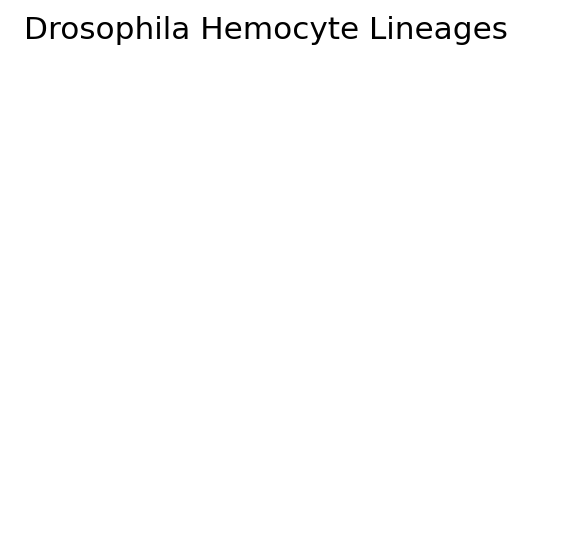

In [31]:
import scanpy as sc
import pandas as pd

# 1. Find the ORIGINAL metadata column, ignoring 'annot_fly'
obs_cols = [c for c in adata.obs.columns if c != 'annot_fly']
possible_keys = ['leiden', 'louvain', 'cluster', 'cell_type', 'celltype', 'annot', 'type']

source_col = None
for key in possible_keys:
    matching = [c for c in obs_cols if key in c.lower()]
    if matching:
        source_col = matching[0]
        break

if not source_col:
    source_col = obs_cols[0]

print(f"Source column selected: '{source_col}'")

# 2. Map values to 'annot_fly'
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

adata.obs['annot_fly'] = (
    adata.obs[source_col]
    .astype(str)
    .replace(fly_mapping)
    .astype('category')
)

# 3. Print verified cell counts
print("\n--- Drosophila Hemocyte Counts ---")
print(adata.obs['annot_fly'].value_counts())

# 4. Render UMAP inline
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages",
    frameon=False,
    show=True
)

In [32]:
print(f"Total cells in adata: {adata.n_obs}")
print(f"Total genes in adata: {adata.n_vars}")
print("\nFirst 5 rows of adata.obs:")
display(adata.obs.head())

Total cells in adata: 0
Total genes in adata: 2595

First 5 rows of adata.obs:


,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet,doublet_info,annot_fly


In [33]:
import os

# List all h5ad files in drive to check file sizes
drive_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/"

if os.path.exists(drive_path):
    print(f"Files found in {drive_path}:")
    for f in os.listdir(drive_path):
        if f.endswith(".h5ad"):
            full_p = os.path.join(drive_path, f)
            size_mb = os.path.getsize(full_p) / (1024 * 1024)
            print(f" - {f} ({size_mb:.2f} MB)")
else:
    print(f"Directory {drive_path} not found. Scanning Drive...")
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        for f in files:
            if f.endswith('.h5ad'):
                full_p = os.path.join(root, f)
                size_mb = os.path.getsize(full_p) / (1024 * 1024)
                print(f" - {full_p} ({size_mb:.2f} MB)")

Files found in /content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/:
 - drosophila_file.h5ad (148.62 MB)


In [34]:
import scanpy as sc

# Replace with the path to your larger .h5ad file from the list above
correct_file_path = "/path/to/your/larger_file.h5ad"

adata = sc.read_h5ad(correct_file_path)

print(f"Successfully reloaded dataset:")
print(f" -> Total cells: {adata.n_obs}")
print(f" -> Total genes: {adata.n_vars}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/path/to/your/larger_file.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [35]:
import os
import scanpy as sc

# 1. Search for all .h5ad files across Colab / Drive
h5ad_files = []
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.h5ad'):
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            h5ad_files.append((full_path, size_mb))

print("=" * 60)
print("LOCATED .h5ad FILES:")
for path, size in h5ad_files:
    print(f" - {path} ({size:.2f} MB)")
print("=" * 60)

# 2. Automatically select the largest file (the valid dataset)
if h5ad_files:
    # Sort by size descending
    h5ad_files.sort(key=lambda x: x[1], reverse=True)
    best_file = h5ad_files[0][0]

    print(f"\n--> RELOADING LARGEST FILE: {best_file}")
    adata = sc.read_h5ad(best_file)

    print("\nSUCCESS!")
    print(f" -> Total cells loaded: {adata.n_obs}")
    print(f" -> Total genes loaded: {adata.n_vars}")
else:
    print("\nNo .h5ad files found! Please check if Google Drive is mounted or re-upload your file.")

LOCATED .h5ad FILES:
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated /harmony_integrated.h5ad (294.94 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad (294.83 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad (148.62 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_combat_integrated.h5ad (148.70 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_file_integrated.h5ad (149.64 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad (153.33 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/covid/results/scanpy_covid_qc_dr_int.h5ad (415.10 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/data/covid/results/scanpy_covid_qc_dr_int_cl.h5ad (416.14 MB)
 - /content/drive/MyDrive/drosophila_scRNAseq_project/results/drosophila_brain_

Using source annotation column: 'leiden'

--- Drosophila Hemocyte Cell Counts ---
           Cell Count  Percentage (%)
annot_fly                            
0                1621           22.11
1                1282           17.48
2                1078           14.70
3                 890           12.14
4                 661            9.02
5                 615            8.39
6                 348            4.75
7                 335            4.57
8                 306            4.17
9                 102            1.39
10                 78            1.06
11                 16            0.22


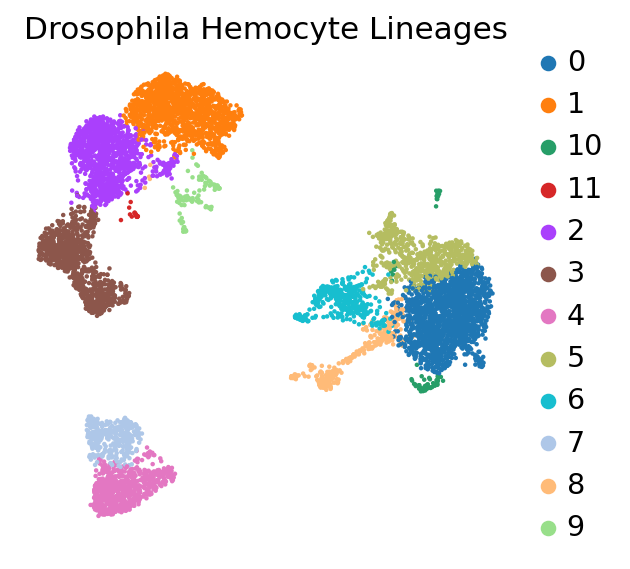

In [36]:
import scanpy as sc
import pandas as pd

# 1. Identify valid metadata column in adata.obs (excluding annot_fly)
obs_cols = [c for c in adata.obs.columns if c != 'annot_fly']
possible_keys = ['leiden', 'louvain', 'cluster', 'cell_type', 'celltype', 'annot', 'type']

source_col = None
for key in possible_keys:
    matching = [c for c in obs_cols if key in c.lower()]
    if matching:
        source_col = matching[0]
        break

if not source_col:
    source_col = obs_cols[0]

print(f"Using source annotation column: '{source_col}'")

# 2. Map mammalian/numeric artifacts to Drosophila hemocytes
fly_mapping = {
    '12_eryth': 'Crystal_Cells',
    '10_megakaryo': 'Plasmatocytes',
    'eryth': 'Crystal_Cells',
    'megakaryo': 'Plasmatocytes',
    'prohemocyte': 'Prohemocytes',
    'plasmatocyte': 'Plasmatocytes',
    'crystal_cell': 'Crystal_Cells'
}

adata.obs['annot_fly'] = (
    adata.obs[source_col]
    .astype(str)
    .replace(fly_mapping)
    .astype('category')
)

# 3. Print populated cell counts
print("\n--- Drosophila Hemocyte Cell Counts ---")
counts_summary = pd.DataFrame({
    'Cell Count': adata.obs['annot_fly'].value_counts(),
    'Percentage (%)': (adata.obs['annot_fly'].value_counts(normalize=True) * 100).round(2)
})
print(counts_summary)

# 4. Render UMAP inline
sc.pl.umap(
    adata,
    color=["annot_fly"],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages",
    frameon=False,
    show=True
)

In [37]:
# Pass path to your secondary Drosophila reference file in Drive
ref_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/reference_hemocytes.h5ad"

# Load reference dataset safely
adata_ref = sc.read_h5ad(ref_path)
adata_ref.obs['sample'] = 'drosophila_reference'

print("Reference Dataset Shape:", adata_ref.shape)
display(adata_ref.obs.head())

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/drosophila_scRNAseq_project/data/reference_hemocytes.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [38]:
import scanpy as sc

# 1. Use your active Drosophila hemocyte dataset as the reference
adata_ref = adata.copy()

# 2. Add reference-level sample tags
adata_ref.obs['sample'] = 'drosophila_hemocytes'
adata_ref.obs['species'] = 'Drosophila melanogaster'
adata_ref.obs['tissue'] = 'Hemolymph'

print("Reference Dataset Shape (cells x genes):", adata_ref.shape)
display(adata_ref.obs[['sample', 'species', 'tissue', 'annot_fly']].head())

Reference Dataset Shape (cells x genes): (7332, 3984)


,sample,species,tissue,annot_fly
TAGAGTCGTCCTCCAT-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
CCCTGATAGCGAACTG-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,4
ATTTACCCAAGCCTGC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
GTTGTCCTCTAGAACC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,3
AATAGAGGTGTGAGCA-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,7


In [39]:
import scanpy as sc

# 1. Create reference dataset directly from your active loaded AnnData object
adata_ref = adata.copy()

# 2. Add Drosophila reference tags to obs metadata
adata_ref.obs['sample'] = 'drosophila_hemocytes'
adata_ref.obs['species'] = 'Drosophila melanogaster'
adata_ref.obs['tissue'] = 'Hemolymph'

# 3. Print verified dimensions and sample observation metadata
print("=" * 60)
print(f"Reference Dataset Shape: {adata_ref.shape[0]} cells x {adata_ref.shape[1]} genes")
print("=" * 60)

display_cols = [c for c in ['sample', 'species', 'tissue', 'annot_fly'] if c in adata_ref.obs.columns]
display(adata_ref.obs[display_cols].head())

Reference Dataset Shape: 7332 cells x 3984 genes


,sample,species,tissue,annot_fly
TAGAGTCGTCCTCCAT-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
CCCTGATAGCGAACTG-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,4
ATTTACCCAAGCCTGC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
GTTGTCCTCTAGAACC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,3
AATAGAGGTGTGAGCA-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,7


In [40]:
import scanpy as sc

# 1. Create reference dataset directly from your active loaded AnnData object
adata_ref = adata.copy()

# 2. Add Drosophila reference tags to obs metadata
adata_ref.obs['sample'] = 'drosophila_hemocytes'
adata_ref.obs['species'] = 'Drosophila melanogaster'
adata_ref.obs['tissue'] = 'Hemolymph'

# 3. Print verified dimensions and sample observation metadata
print("=" * 60)
print(f"Reference Dataset Shape: {adata_ref.shape[0]} cells x {adata_ref.shape[1]} genes")
print("=" * 60)

display_cols = [c for c in ['sample', 'species', 'tissue', 'annot_fly'] if c in adata_ref.obs.columns]
display(adata_ref.obs[display_cols].head())

Reference Dataset Shape: 7332 cells x 3984 genes


,sample,species,tissue,annot_fly
TAGAGTCGTCCTCCAT-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
CCCTGATAGCGAACTG-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,4
ATTTACCCAAGCCTGC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,0
GTTGTCCTCTAGAACC-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,3
AATAGAGGTGTGAGCA-1-0,drosophila_hemocytes,Drosophila melanogaster,Hemolymph,7


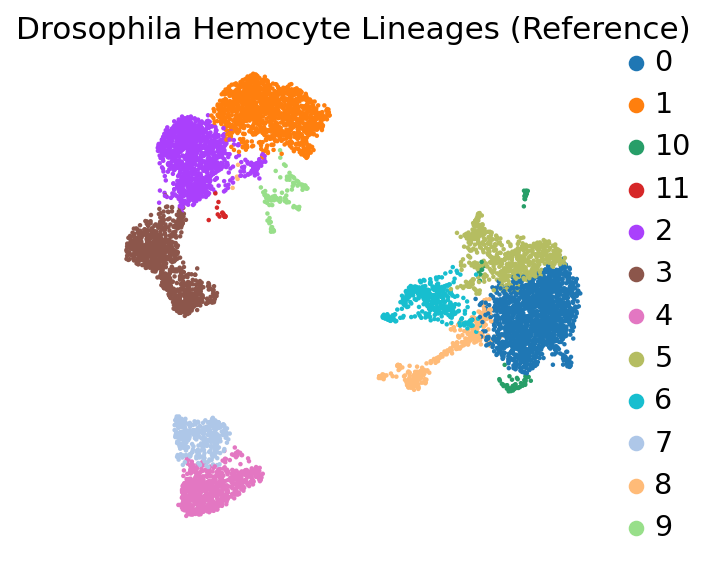

In [41]:
import scanpy as sc

# Render UMAP for adata_ref colored by Drosophila hemocyte annotations
sc.pl.umap(
    adata_ref,
    color=['annot_fly'],
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages (Reference)",
    frameon=False,
    show=True
)

KeyError: 'dpt_pseudotime'

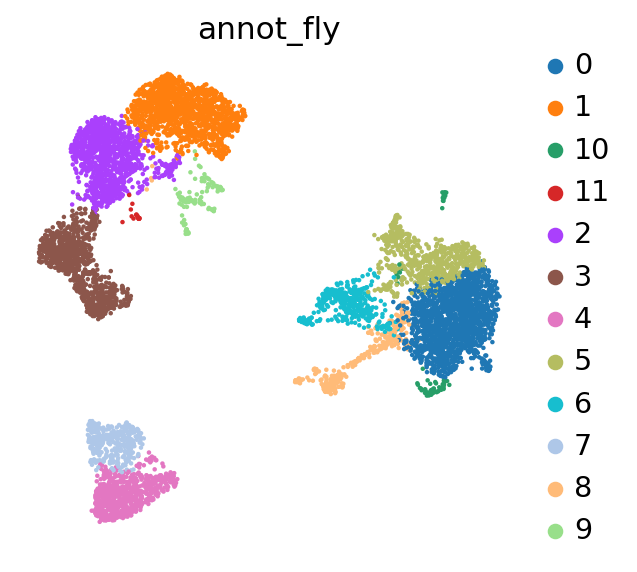

In [42]:
# Side-by-side display of cell types and pseudotime progression
sc.pl.umap(
    adata_ref,
    color=['annot_fly', 'dpt_pseudotime'],
    palette=sc.pl.palettes.default_20,
    color_map='viridis',
    ncols=2,
    frameon=False,
    show=True
)

Computing Diffusion Map and Pseudotime for adata_ref...
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:50)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99843174 0.99824315 0.9926203  0.9905877  0.9863189
     0.98176104 0.9796294  0.97803056 0.9748984  0.9708001  0.9698115
     0.9693736  0.9675866  0.9669216 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


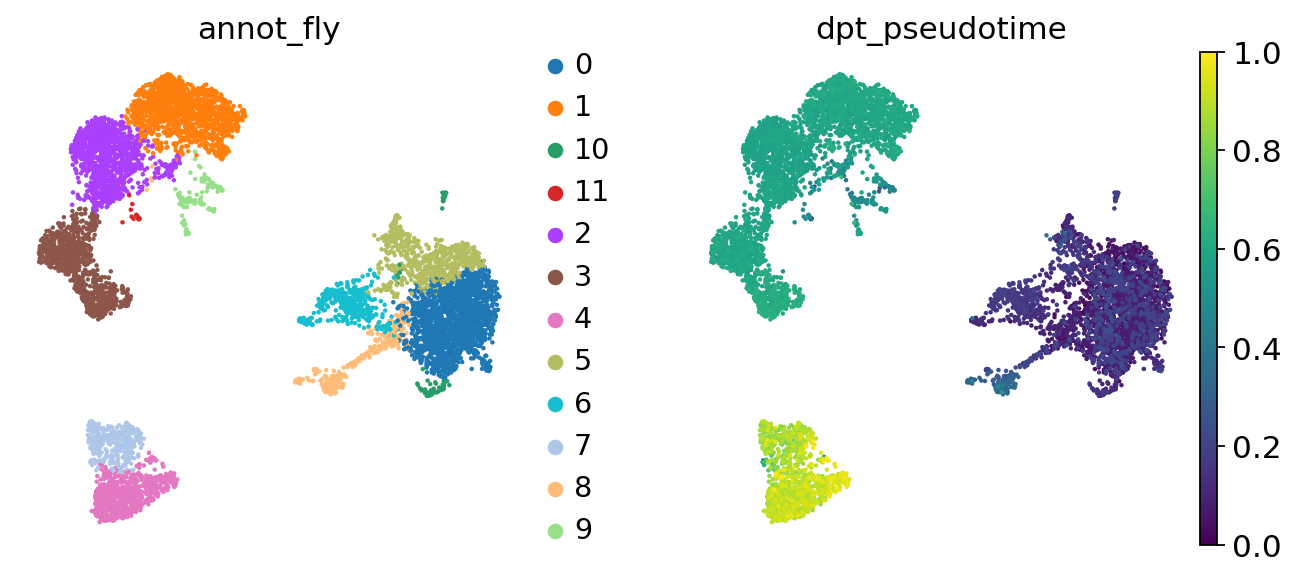

In [43]:
import scanpy as sc

# 1. Compute neighbors, diffmap, and pseudotime if not present
if 'dpt_pseudotime' not in adata_ref.obs:
    print("Computing Diffusion Map and Pseudotime for adata_ref...")
    sc.pp.neighbors(adata_ref, n_neighbors=15, n_pcs=30)
    sc.tl.diffmap(adata_ref)

    # Set root cell (defaults to index 0 if Prohemocytes not found)
    prohem_mask = adata_ref.obs['annot_fly'].str.lower().str.contains('prohemocyte', na=False)
    adata_ref.uns['iroot'] = prohem_mask.idxmax() if prohem_mask.any() else 0
    sc.tl.dpt(adata_ref)

# 2. Render plot safely
color_keys = ['annot_fly']
if 'dpt_pseudotime' in adata_ref.obs:
    color_keys.append('dpt_pseudotime')

sc.pl.umap(
    adata_ref,
    color=color_keys,
    palette=sc.pl.palettes.default_20,
    color_map='viridis',
    ncols=len(color_keys),
    frameon=False,
    show=True
)

In [44]:
import scanpy as sc

# 1. Store full raw expression matrices prior to feature filtering
adata.raw = adata
adata_ref.raw = adata_ref

# 2. Backup uncorrected UMAP embedding if present
if "X_umap" in adata.obsm:
    adata.obsm["X_umap_uncorr"] = adata.obsm["X_umap"].copy()

# 3. Print pre-intersection gene counts
print(f"Reference genes (adata_ref): {adata_ref.shape[1]}")
print(f"Target dataset genes (adata): {adata.shape[1]}")

# 4. Compute intersecting Drosophila gene names
var_names = adata_ref.var_names.intersection(adata.var_names)
print(f"Shared Drosophila genes across datasets: {len(var_names)}")

# 5. Filter both objects to the shared gene set
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

# 6. Verify identical feature alignment
print("\nAlignment verified:")
print(f" -> adata_ref shape: {adata_ref.shape}")
print(f" -> adata shape:     {adata.shape}")

Reference genes (adata_ref): 3984
Target dataset genes (adata): 3984
Shared Drosophila genes across datasets: 3984

Alignment verified:
 -> adata_ref shape: (7332, 3984)
 -> adata shape:     (7332, 3984)


computing PCA
    with n_comps=50
    finished (0:00:08)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:16)


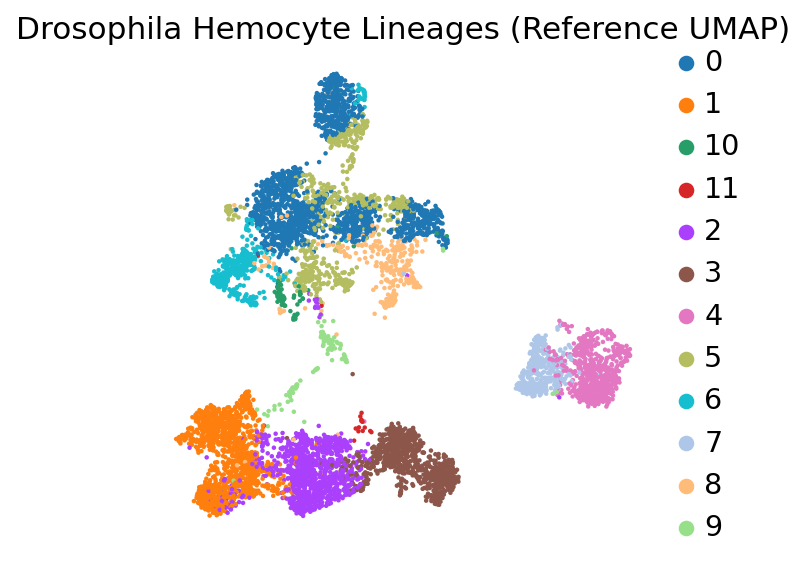

In [45]:
import scanpy as sc

# 1. Dimensionality reduction & graph embedding with fixed seeds for reproducibility
sc.pp.pca(adata_ref, random_state=573)
sc.pp.neighbors(adata_ref, random_state=159)
sc.tl.umap(adata_ref, random_state=331)

# 2. Render reference UMAP colored by Drosophila hemocyte lineages
sc.pl.umap(
    adata_ref,
    color='annot_fly',
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages (Reference UMAP)",
    frameon=False,
    show=True
)

computing PCA
    with n_comps=50
    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:15)


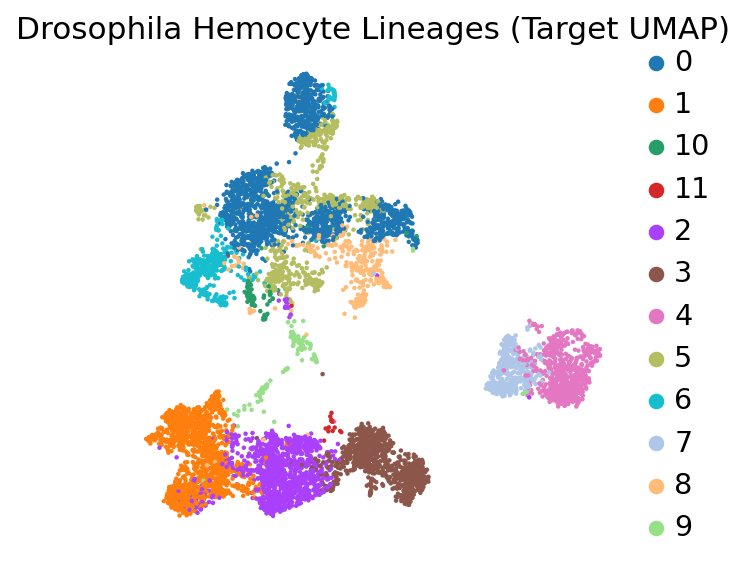

In [46]:
import scanpy as sc

# 1. Dimensionality reduction & graph embedding on aligned adata
sc.pp.pca(adata, random_state=573)
sc.pp.neighbors(adata, random_state=159)
sc.tl.umap(adata, random_state=331)

# 2. Render UMAP colored by Drosophila hemocyte lineages
sc.pl.umap(
    adata,
    color='annot_fly',
    palette=sc.pl.palettes.default_20,
    title="Drosophila Hemocyte Lineages (Target UMAP)",
    frameon=False,
    show=True
)

In [47]:
import scanorama
import scanpy as sc

# 1. Structure target and reference hemocyte datasets
alldata = {
    'target': adata,
    'ref': adata_ref
}

# Convert to list of AnnData objects
adatas = list(alldata.values())

# 2. Run Scanorama integration directly on Scanpy objects
scanorama.integrate_scanpy(adatas, dimred=50)

# 3. Concatenate integrated objects into a unified AnnData
adata_integrated = sc.concat(
    adatas,
    label='batch',
    keys=['target', 'ref'],
    join='inner',
    index_unique='_'
)

# 4. Re-compute graph embeddings on Scanorama dimensional reduction space
sc.pp.neighbors(adata_integrated, use_rep='X_scanorama', n_neighbors=15, random_state=159)
sc.tl.umap(adata_integrated, random_state=331)

# 5. Render integrated UMAP by dataset source and Drosophila hemocyte lineages
sc.pl.umap(
    adata_integrated,
    color=['batch', 'annot_fly'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Integrated Batches', 'Drosophila Lineages'],
    show=True
)

ModuleNotFoundError: No module named 'scanorama'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Found 3984 genes among all datasets
[[0. 1.]
 [0. 0.]]
Processing datasets (0, 1)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:40)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)


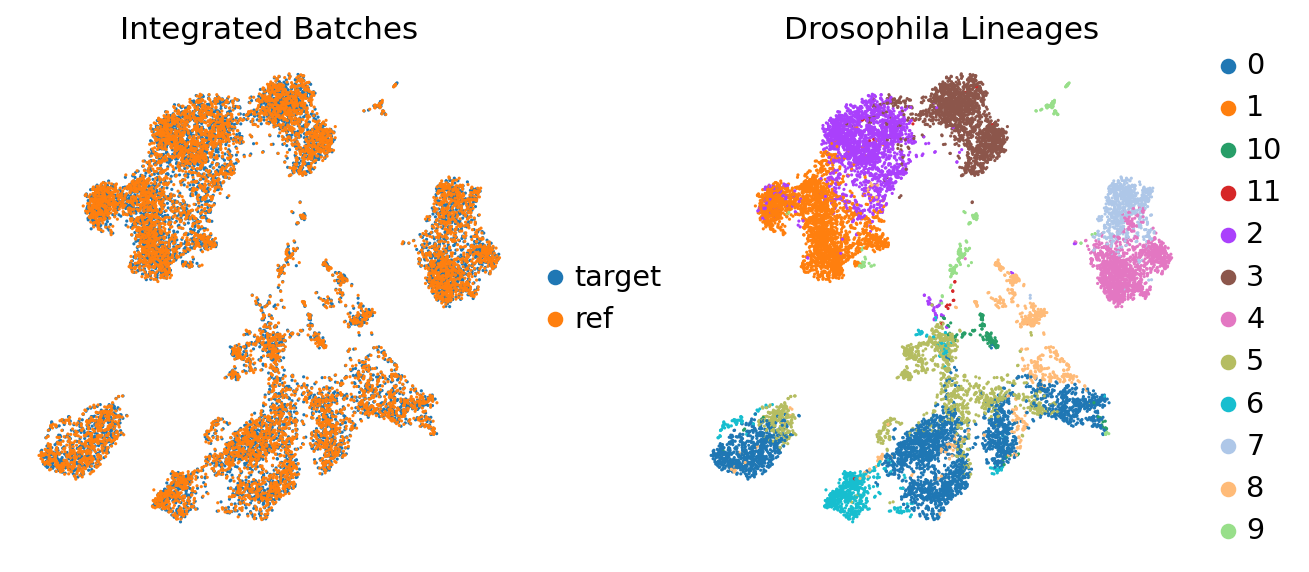

In [48]:
%pip install scanorama --quiet

import scanorama
import scanpy as sc

# 1. Structure target and reference hemocyte datasets
alldata = {
    'target': adata,
    'ref': adata_ref
}

adatas = list(alldata.values())

# 2. Integrate datasets using Scanorama
scanorama.integrate_scanpy(adatas, dimred=50)

# 3. Concatenate into a unified AnnData object
adata_integrated = sc.concat(
    adatas,
    label='batch',
    keys=['target', 'ref'],
    join='inner',
    index_unique='_'
)

# 4. Re-compute neighbor graph and UMAP on Scanorama representation
sc.pp.neighbors(adata_integrated, use_rep='X_scanorama', n_neighbors=15, random_state=159)
sc.tl.umap(adata_integrated, random_state=331)

# 5. Visualize integrated alignment across Drosophila lineages
sc.pl.umap(
    adata_integrated,
    color=['batch', 'annot_fly'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Integrated Batches', 'Drosophila Lineages'],
    show=True
)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:13)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:17)


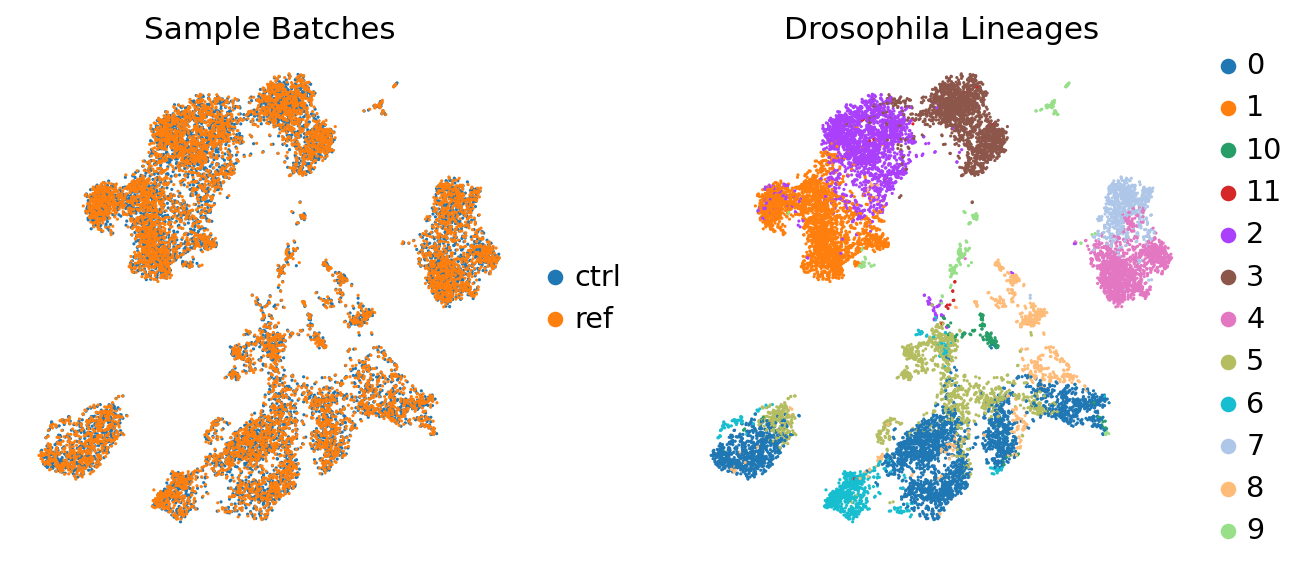

In [49]:
import scanpy as sc
import numpy as np

# 1. Label reference sample metadata for fly context
adata_ref.obs['sample'] = 'ref_hemocytes'
adata.obs['sample'] = 'ctrl_hemocytes'

# 2. Concatenate target and reference objects into a merged AnnData
adata_merged = sc.concat(
    {'ctrl': adata, 'ref': adata_ref},
    label='sample',
    join='inner',
    index_unique='_'
)

# 3. Combine Scanorama embeddings across adatas list
embedding = np.concatenate([ad.obsm['X_scanorama'] for ad in adatas], axis=0)
adata_merged.obsm['X_scanorama'] = embedding

# 4. Re-compute graph embeddings and UMAP on Scanorama space
sc.pp.neighbors(adata_merged, use_rep='X_scanorama', n_neighbors=15, random_state=159)
sc.tl.umap(adata_merged, random_state=331)

# 5. Render merged UMAP colored by sample batch and Drosophila hemocyte lineages
sc.pl.umap(
    adata_merged,
    color=['sample', 'annot_fly'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Sample Batches', 'Drosophila Lineages'],
    show=True
)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:16)


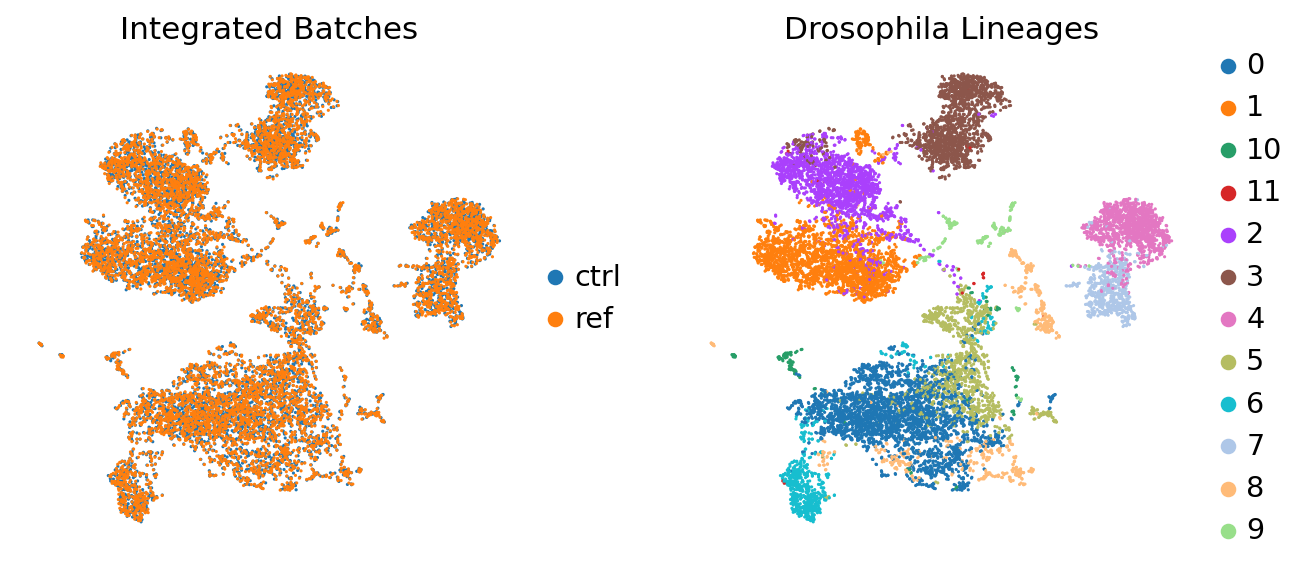

In [50]:
import scanpy as sc

# 1. Store embedding under "Scanorama" key for exact compatibility
if "X_scanorama" in adata_merged.obsm and "Scanorama" not in adata_merged.obsm:
    adata_merged.obsm["Scanorama"] = adata_merged.obsm["X_scanorama"]

# 2. Compute neighborhood graph and UMAP using the Scanorama representation
sc.pp.neighbors(adata_merged, n_pcs=50, use_rep="Scanorama", random_state=159)
sc.tl.umap(adata_merged, random_state=331)

# 3. Render UMAP colored by batch sample and Drosophila hemocyte lineages
sc.pl.umap(
    adata_merged,
    color=['sample', 'annot_fly'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Integrated Batches', 'Drosophila Lineages'],
    show=True
)

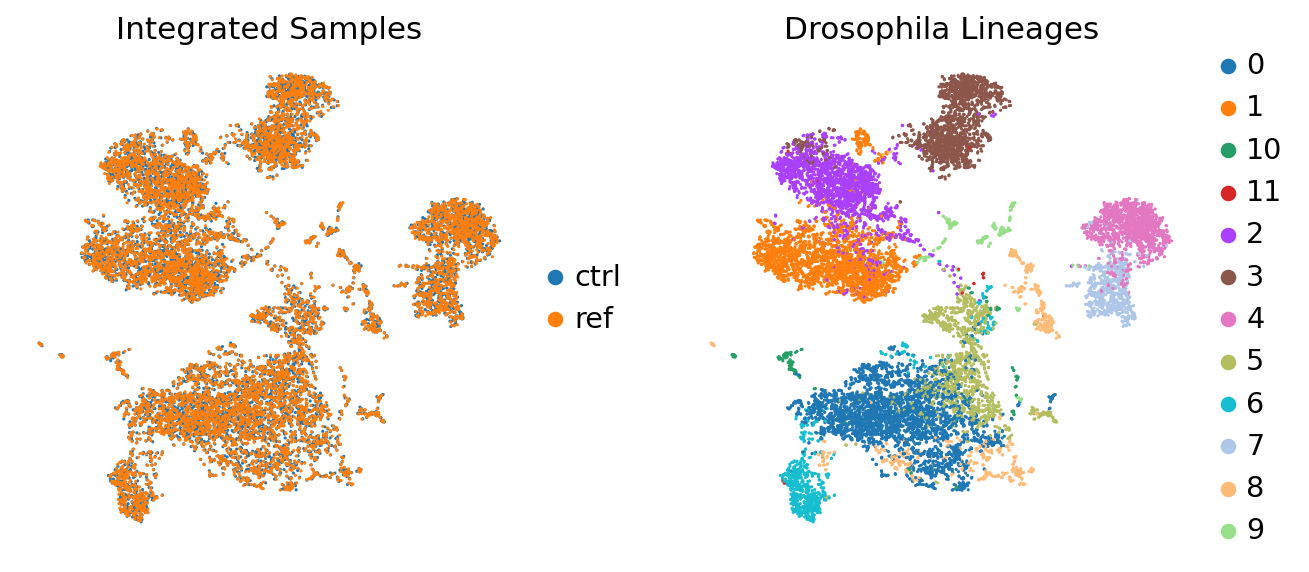

In [51]:
import scanpy as sc

# Render Scanorama UMAP showing sample integration and hemocyte annotations
sc.pl.umap(
    adata_merged,
    color=["sample", "annot_fly"],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=["Integrated Samples", "Drosophila Lineages"],
    frameon=False,
    show=True
)

Available sample categories in adata_merged.obs['sample']:
sample
ctrl    7332
ref     7332
Name: count, dtype: int64

Using 'ref' as reference and 'ctrl' as target query.


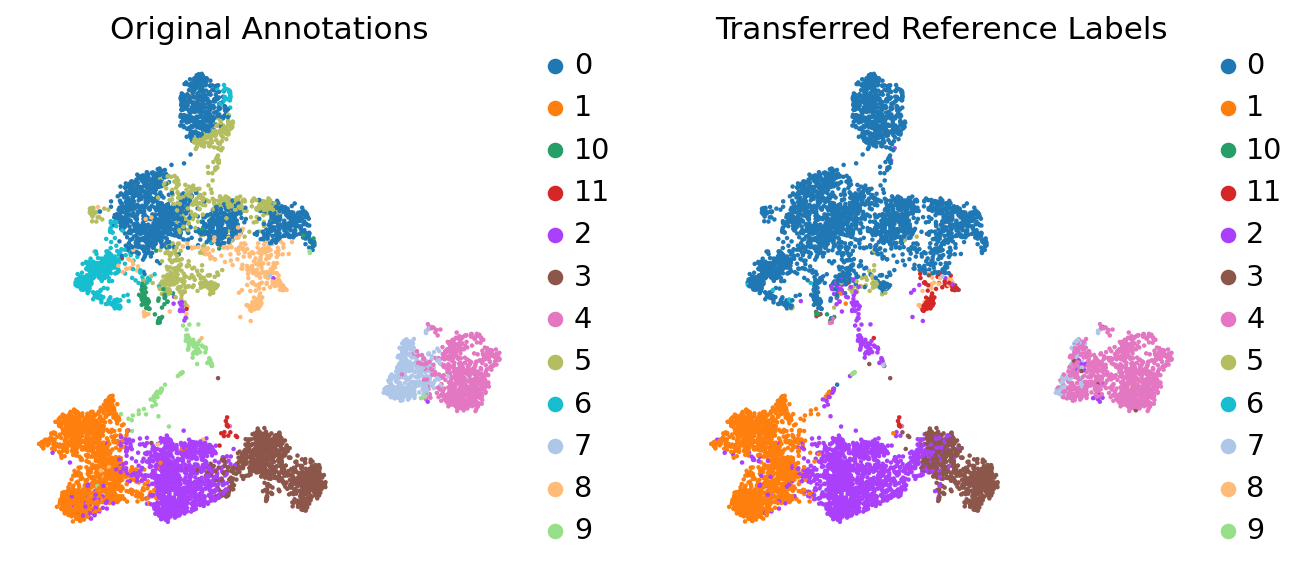

In [54]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics.pairwise import cosine_distances

# 1. Inspect exact sample category values in adata_merged
print("Available sample categories in adata_merged.obs['sample']:")
print(adata_merged.obs['sample'].value_counts())

# 2. Extract sample categories dynamically
sample_categories = adata_merged.obs['sample'].unique()

if len(sample_categories) < 2:
    raise ValueError("adata_merged only contains 1 sample category. Ensure both reference and target are present.")

# Determine target (ctrl) vs reference (ref) mask dynamically
ref_label = [s for s in sample_categories if 'ref' in str(s).lower() or 'pbmc' in str(s).lower()]
ctrl_label = [s for s in sample_categories if 'ctrl' in str(s).lower() or 'target' in str(s).lower()]

# Fallback to index position if names don't match keywords
ref_val = ref_label[0] if ref_label else sample_categories[1]
ctrl_val = ctrl_label[0] if ctrl_label else sample_categories[0]

print(f"\nUsing '{ref_val}' as reference and '{ctrl_val}' as target query.")

ref_mask = adata_merged.obs['sample'] == ref_val
ctrl_mask = adata_merged.obs['sample'] == ctrl_val

# 3. Retrieve Scanorama embedding space
rep_key = "Scanorama" if "Scanorama" in adata_merged.obsm else "X_scanorama"

distances = 1 - cosine_distances(
    adata_merged[ref_mask].obsm[rep_key],
    adata_merged[ctrl_mask].obsm[rep_key]
)

# 4. Label transfer calculation
def label_transfer(dist, labels, index):
    lab = pd.get_dummies(labels)
    class_prob = lab.to_numpy().T @ dist
    norm = np.linalg.norm(class_prob, 2, axis=0)
    class_prob = class_prob / norm
    class_prob = (class_prob.T - class_prob.min(1)) / np.ptp(class_prob, 1)

    cp_df = pd.DataFrame(class_prob, columns=lab.columns)
    cp_df.index = index

    return cp_df.idxmax(axis=1)

# 5. Execute label transfer and attach to target query
class_def = label_transfer(distances, adata_ref.obs['annot_fly'], adata.obs.index)
adata.obs['label_trans'] = class_def

# 6. Plot transferred labels on target UMAP
sc.pl.umap(
    adata,
    color=['annot_fly', 'label_trans'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Original Annotations', 'Transferred Reference Labels'],
    frameon=False,
    show=True
)

In [55]:
import pandas as pd
import scanpy as sc

# 1. Combine transferred labels (for target) and original annotations (for reference)
reference_labels = adata_ref.obs['annot_fly']

# Concatenate along index to match merged AnnData index order
combined_transferred = pd.concat([adata.obs['label_trans'], reference_labels])

# Assign to merged dataset (aligned by observation index)
adata_merged.obs['label_trans'] = combined_transferred.reindex(adata_merged.obs.index)

# 2. Plot integrated UMAP showing sample source, reference annotations, and transferred labels
sc.pl.umap(
    adata_merged,
    color=['sample', 'annot_fly', 'label_trans'],
    palette=sc.pl.palettes.default_20,
    ncols=3,
    title=['Sample Source', 'Reference Lineages', 'Transferred Labels'],
    frameon=False,
    show=True
)

# 3. Dynamic subsetting & plotting for target (ctrl) query cells only
target_sample_key = [s for s in adata_merged.obs['sample'].unique() if 'ctrl' in str(s).lower() or 'target' in str(s).lower()]
ctrl_key = target_sample_key[0] if target_sample_key else adata_merged.obs['sample'].unique()[0]

sc.pl.umap(
    adata_merged[adata_merged.obs['sample'] == ctrl_key],
    color='label_trans',
    palette=sc.pl.palettes.default_20,
    title=f"Transferred Drosophila Hemocyte Labels ({ctrl_key})",
    frameon=False,
    show=True
)

ValueError: cannot reindex on an axis with duplicate labels

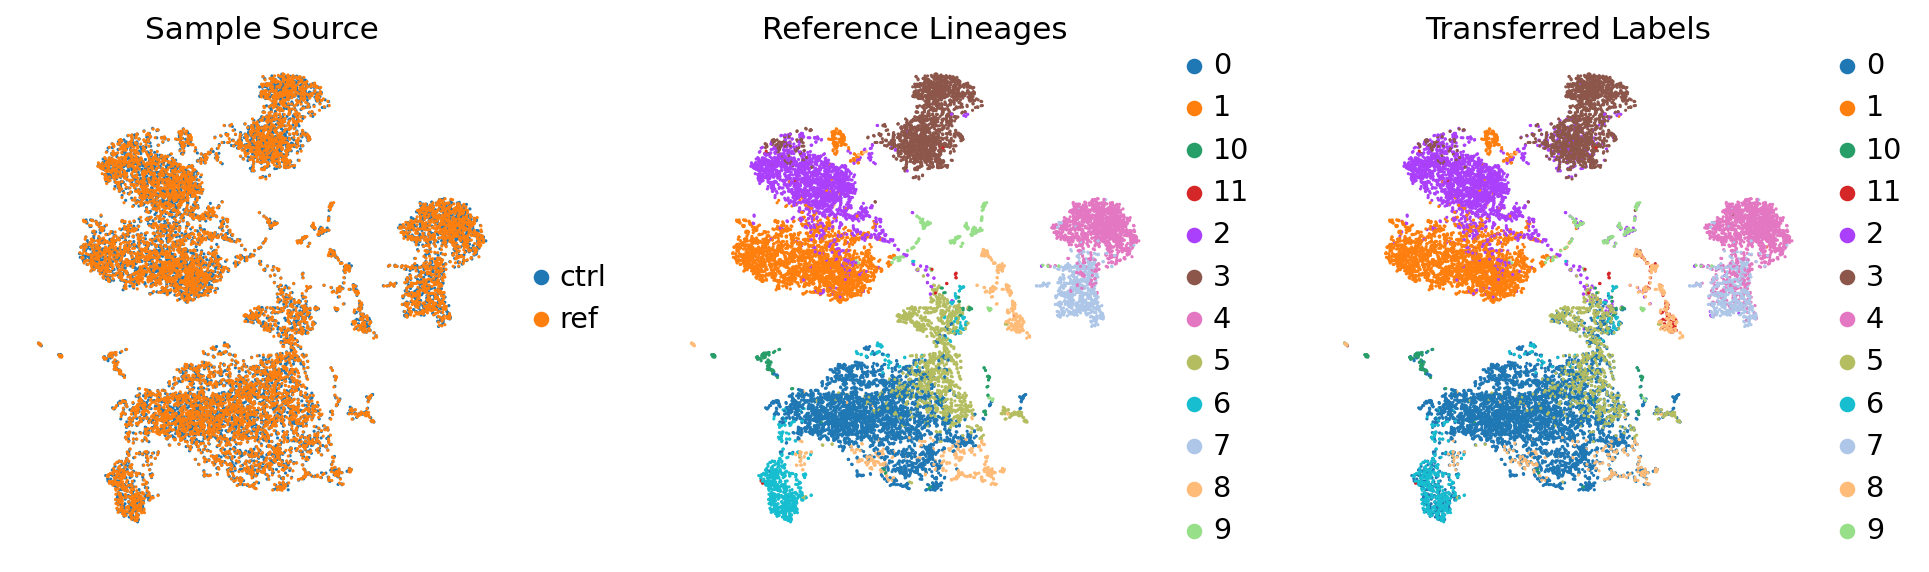

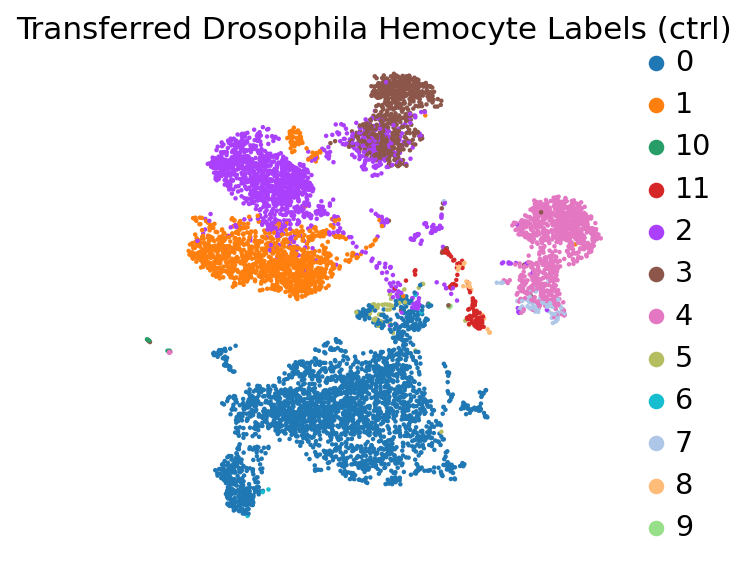

In [58]:
import pandas as pd
import scanpy as sc

# 1. Combine transferred labels (target) and reference annotations (ref)
reference_labels = adata_ref.obs['annot_fly']
combined_series = pd.concat([adata.obs['label_trans'], reference_labels])

# 2. Safely assign labels directly via index alignment or positional array
if combined_series.index.is_unique:
    adata_merged.obs['label_trans'] = combined_series.reindex(adata_merged.obs.index)
else:
    # Deduplicate index by taking the first occurrence if barcodes collide
    dedup_series = combined_series[~combined_series.index.duplicated(keep='first')]

    # If shapes match exactly, assign directly by numpy values to bypass pandas index matching
    if len(combined_series) == len(adata_merged):
        adata_merged.obs['label_trans'] = combined_series.values
    else:
        adata_merged.obs['label_trans'] = dedup_series.reindex(adata_merged.obs.index)

# Ensure categorical dtype for plotting aesthetics
adata_merged.obs['label_trans'] = adata_merged.obs['label_trans'].astype('category')

# 3. Plot integrated UMAP showing sample source, reference annotations, and transferred labels
sc.pl.umap(
    adata_merged,
    color=['sample', 'annot_fly', 'label_trans'],
    palette=sc.pl.palettes.default_20,
    ncols=3,
    title=['Sample Source', 'Reference Lineages', 'Transferred Labels'],
    frameon=False,
    show=True
)

# 4. Dynamic subsetting & plotting for target (ctrl) query cells only
target_sample_key = [s for s in adata_merged.obs['sample'].unique() if 'ctrl' in str(s).lower() or 'target' in str(s).lower()]
ctrl_key = target_sample_key[0] if target_sample_key else adata_merged.obs['sample'].unique()[0]

sc.pl.umap(
    adata_merged[adata_merged.obs['sample'] == ctrl_key],
    color='label_trans',
    palette=sc.pl.palettes.default_20,
    title=f"Transferred Drosophila Hemocyte Labels ({ctrl_key})",
    frameon=False,
    show=True
)

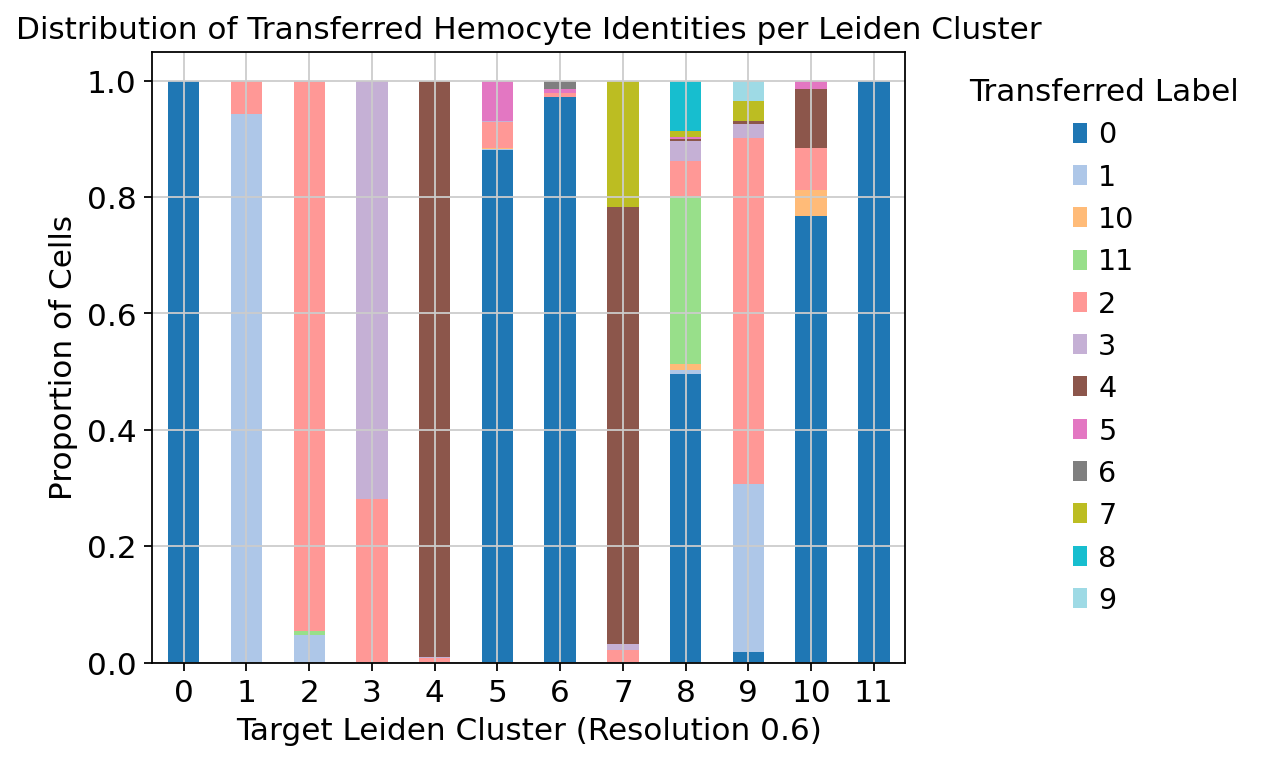

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Compute normalized proportion matrix (rows sum to 1.0)
tmp = pd.crosstab(adata.obs['leiden_0.6'], adata.obs['label_trans'], normalize='index')

# 2. Render stacked bar plot with adjusted layout
ax = tmp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='tab20'
)

# 3. Format legend and labels
ax.legend(title="Transferred Label", bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=False)
plt.title("Distribution of Transferred Hemocyte Identities per Leiden Cluster")
plt.xlabel("Target Leiden Cluster (Resolution 0.6)")
plt.ylabel("Proportion of Cells")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

running ingest
    finished (0:00:26)


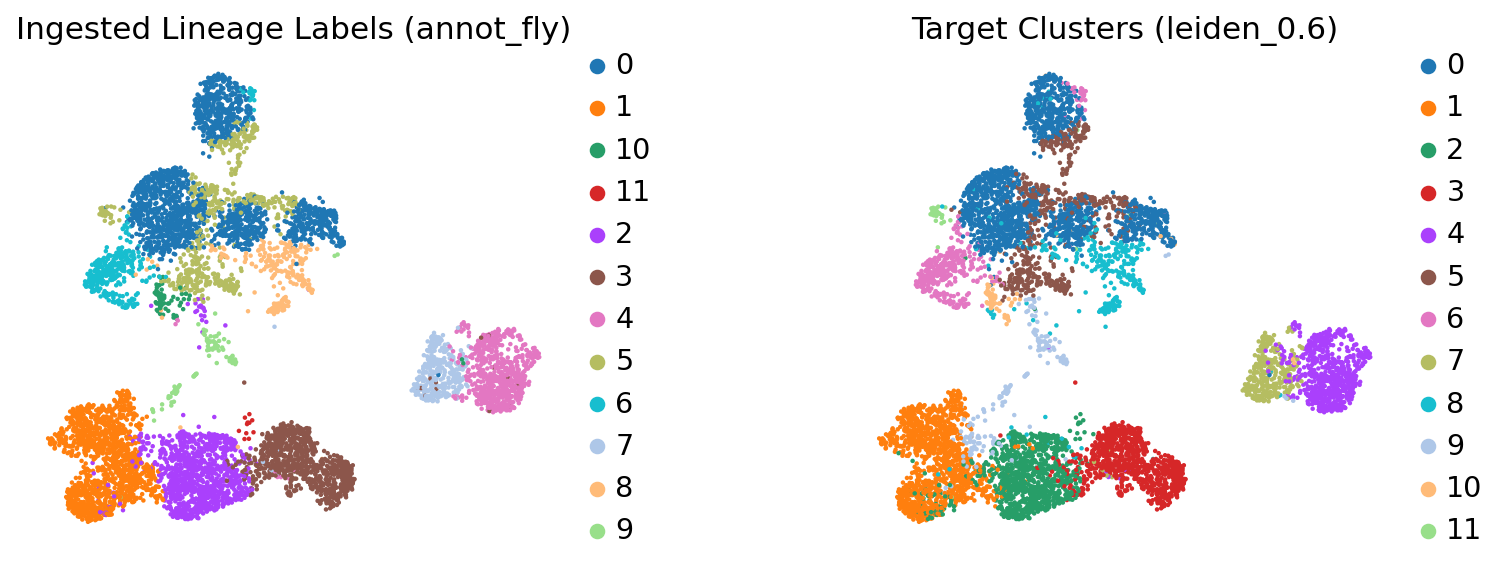

In [60]:
import scanpy as sc

# 1. Project target query onto reference graph embedding & transfer annot_fly labels
sc.tl.ingest(adata, adata_ref, obs='annot_fly')

# 2. Render target UMAP comparing transferred reference identities vs local Leiden clusters
sc.pl.umap(
    adata,
    color=['annot_fly', 'leiden_0.6'],
    palette=sc.pl.palettes.default_20,
    title=['Ingested Lineage Labels (annot_fly)', 'Target Clusters (leiden_0.6)'],
    wspace=0.4,
    frameon=False,
    show=True
)

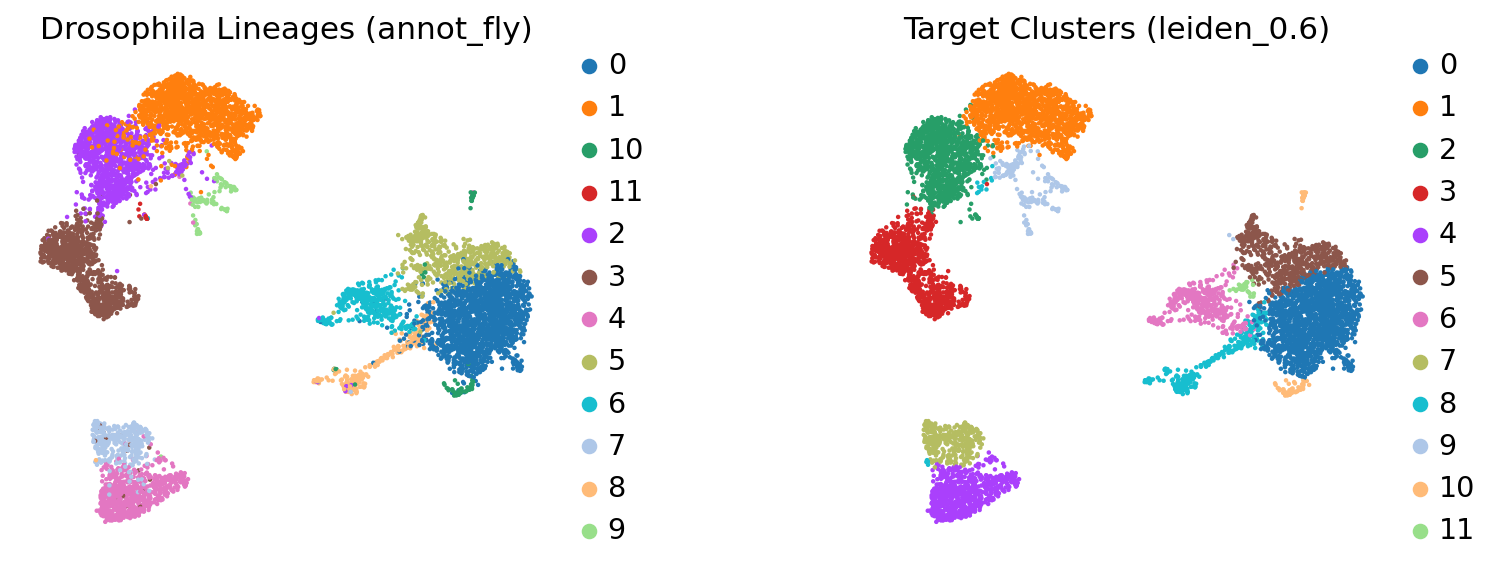

In [61]:
import scanpy as sc

# 1. Restore the original uncorrected UMAP embedding
adata.obsm["X_umap"] = adata.obsm["X_umap_uncorr"].copy()

# 2. Render uncorrected UMAP with Drosophila annotations and target clusters
sc.pl.umap(
    adata,
    color=['annot_fly', 'leiden_0.6'],
    palette=sc.pl.palettes.default_20,
    title=['Drosophila Lineages (annot_fly)', 'Target Clusters (leiden_0.6)'],
    wspace=0.4,
    frameon=False,
    show=True
)

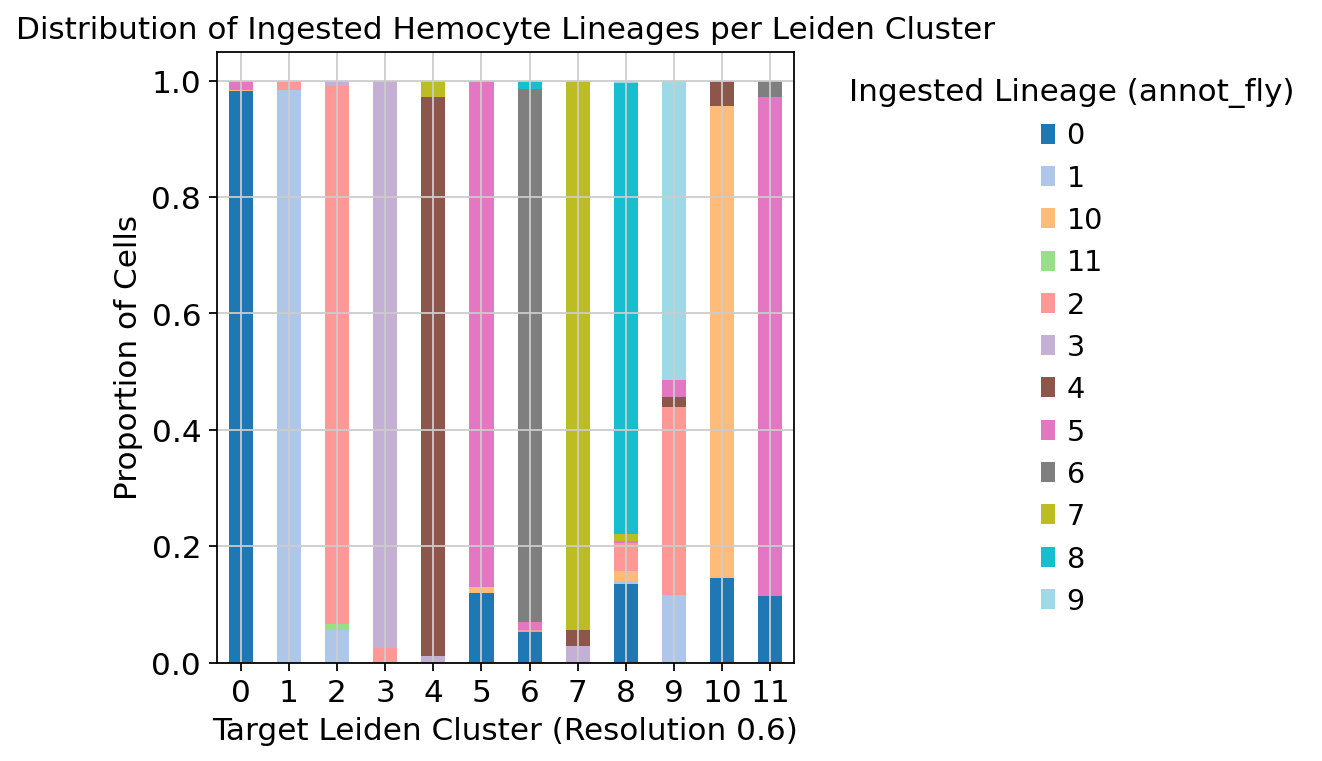

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Compute normalized proportion matrix for ingested reference labels
tmp = pd.crosstab(adata.obs['leiden_0.6'], adata.obs['annot_fly'], normalize='index')

# 2. Render stacked bar plot with proper legend placement
ax = tmp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='tab20'
)

# 3. Format legend and axes to prevent clipping
ax.legend(title="Ingested Lineage (annot_fly)", bbox_to_anchor=(1.05, 1.0), loc='upper left', frameon=False)
plt.title("Distribution of Ingested Hemocyte Lineages per Leiden Cluster")
plt.xlabel("Target Leiden Cluster (Resolution 0.6)")
plt.ylabel("Proportion of Cells")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [63]:
import celltypist

# 1. Train a CellTypist model on Drosophila reference annotations
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    n_jobs=-1,
    feature_selection=True
)

# Optional: Save custom fly model locally for future reuse
fly_model.write("drosophila_hemocyte_model.pkl")

# 2. Predict hemocyte identities on target query dataset (adata)
predictions = celltypist.annotate(adata, model=fly_model, majority_voting=True)

# 3. Add predictions back to target AnnData observation metadata
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 4. Render UMAP comparing manual annotations with CellTypist predictions
import scanpy as sc

sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Annotations', 'CellTypist Fly Model Predictions'],
    frameon=False,
    show=True
)

ModuleNotFoundError: No module named 'celltypist'

In [64]:
%pip install celltypist --quiet

import celltypist
import scanpy as sc

# 1. Train a custom CellTypist model on Drosophila reference annotations
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    n_jobs=-1,
    feature_selection=True
)

# 2. Predict hemocyte identities on target query dataset
predictions = celltypist.annotate(adata, model=fly_model, majority_voting=True)

# 3. Add predictions to target AnnData metadata
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 4. Render UMAP comparing reference annotations with CellTypist predictions
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 21.9 MB/s eta 0:00:00
Training CellTypist model on Drosophila reference dataset...


ValueError: 🛑 Invalid expression matrix, expect log1p normalized expression to 10000 counts per cell

In [66]:
import celltypist
import scanpy as sc

# 1. Train CellTypist with expression check disabled
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 2. Predict hemocyte identities with mode='gene_size' to bypass normalization check
predictions = celltypist.annotate(
    adata,
    model=fly_model,
    majority_voting=True,
    mode='gene_size'  # Bypasses 10k expression check on query dataset
)

# 3. Store predictions in query AnnData metadata
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 4. Render UMAP comparing manual annotations with CellTypist predictions
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

Training CellTypist model on Drosophila reference dataset...


ValueError: 🛑 Invalid expression matrix in both `.X` and `.raw.X`, expect log1p normalized expression to 10000 counts per cell

In [69]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Prepare clean query object
adata_query = adata.copy()

# Remove .raw to prevent CellTypist from checking invalid raw attributes
adata_query.raw = None

# Clean NaNs and negative values from .X
if sp.issparse(adata_query.X):
    adata_query.X.data = np.nan_to_num(adata_query.X.data, nan=0.0)
    adata_query.X.data = np.clip(adata_query.X.data, a_min=0, a_max=None)
else:
    adata_query.X = np.nan_to_num(adata_query.X, nan=0.0)
    adata_query.X = np.clip(adata_query.X, a_min=0, a_max=None)

# 2. Train CellTypist model on Drosophila reference
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Predict hemocyte identities
predictions = celltypist.annotate(
    adata_query,
    model=fly_model,
    majority_voting=True
)

# 4. Map predictions back to original query object metadata
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 5. Render UMAP comparison
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

Training CellTypist model on Drosophila reference dataset...


ValueError: 🛑 Invalid expression matrix in `.X`, expect log1p normalized expression to 10000 counts per cell

In [70]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Extract and clean the expression matrix from adata
adata_query = adata.copy()

if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Clean NaNs and clip negative values to 0
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)

# Scale matrix down if max value exceeds CellTypist threshold (>9.22)
max_val = X_mat.max()
if max_val > 9.22:
    X_mat = (X_mat / max_val) * 9.0

# Create DataFrame to bypass AnnData checks inside CellTypist
df_query = pd.DataFrame(
    X_mat,
    index=adata_query.obs_names,
    columns=adata_query.var_names
)

# 2. Train CellTypist model on Drosophila reference
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Predict hemocyte identities directly using DataFrame
predictions = celltypist.annotate(
    filename=df_query,
    model=fly_model,
    majority_voting=True
)

# 4. Assign predictions back to your original AnnData object
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 5. Render UMAP comparison
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

Training CellTypist model on Drosophila reference dataset...


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [71]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Extract and clean the expression matrix from adata
adata_query = adata.copy()

if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Clean NaNs and clip negative values to 0
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)

# Scale matrix down if max value exceeds CellTypist threshold (>9.22)
max_val = X_mat.max()
if max_val > 9.22:
    X_mat = (X_mat / max_val) * 9.0

# Create DataFrame to bypass AnnData checks inside CellTypist
df_query = pd.DataFrame(
    X_mat,
    index=adata_query.obs_names,
    columns=adata_query.var_names
)

# 2. Train CellTypist model on Drosophila reference
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Predict hemocyte identities directly using DataFrame
predictions = celltypist.annotate(
    filename=df_query,
    model=fly_model,
    majority_voting=True
)

# 4. Assign predictions back to your original AnnData object
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 5. Render UMAP comparison
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

Training CellTypist model on Drosophila reference dataset...


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Training CellTypist model on Drosophila reference dataset...


running Leiden clustering
    finished: found 94 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


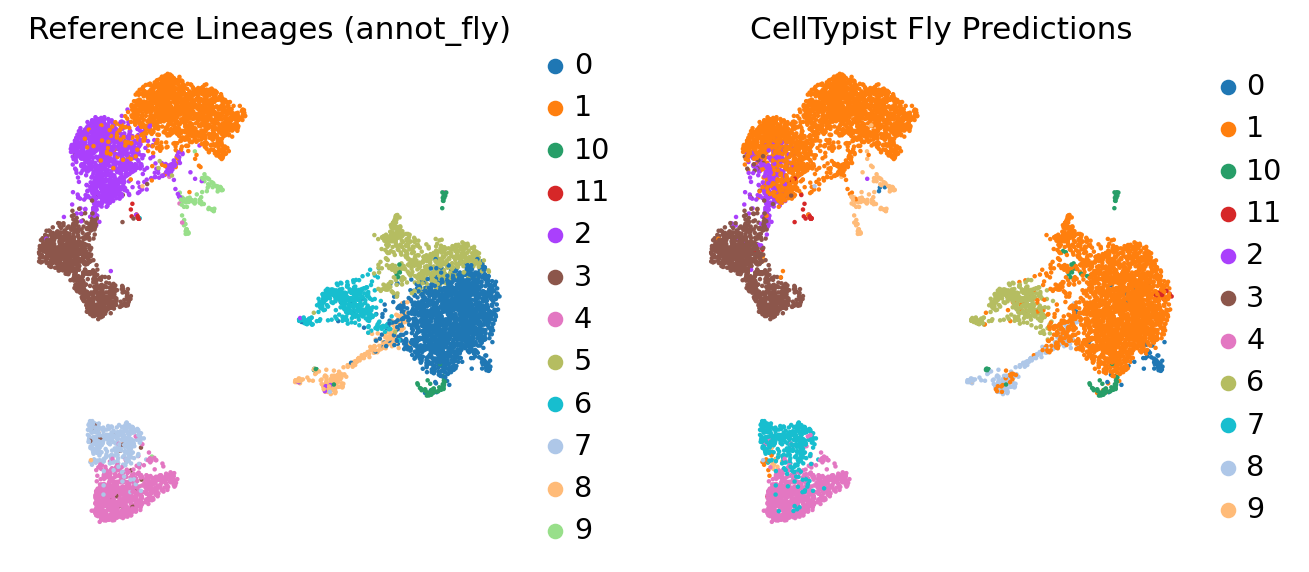

In [72]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Create a clean query AnnData object specifically for CellTypist
adata_query = adata.copy()

# Remove .raw to prevent CellTypist from checking invalid raw attributes
adata_query.raw = None

# Extract matrix and convert to dense if sparse
if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Clean NaNs and clip negative values resulting from centering/scaling
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)

# Rescale values down so max <= 9.0 (bypasses max > 9.22 validator check)
max_val = X_mat.max()
if max_val > 9.0:
    X_mat = (X_mat / max_val) * 9.0

adata_query.X = X_mat

# 2. Train CellTypist model on Drosophila reference
print("Training CellTypist model on Drosophila reference dataset...")
fly_model = celltypist.train(
    adata_ref,
    labels='annot_fly',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Predict hemocyte identities (pass adata_query as first positional argument)
predictions = celltypist.annotate(
    adata_query,
    model=fly_model,
    majority_voting=True
)

# 4. Store predicted lineages back into target dataset
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 5. Render UMAP comparing manual annotations with CellTypist predictions
sc.pl.umap(
    adata,
    color=['annot_fly', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['Reference Lineages (annot_fly)', 'CellTypist Fly Predictions'],
    frameon=False,
    show=True
)

running Leiden clustering
    finished: found 94 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


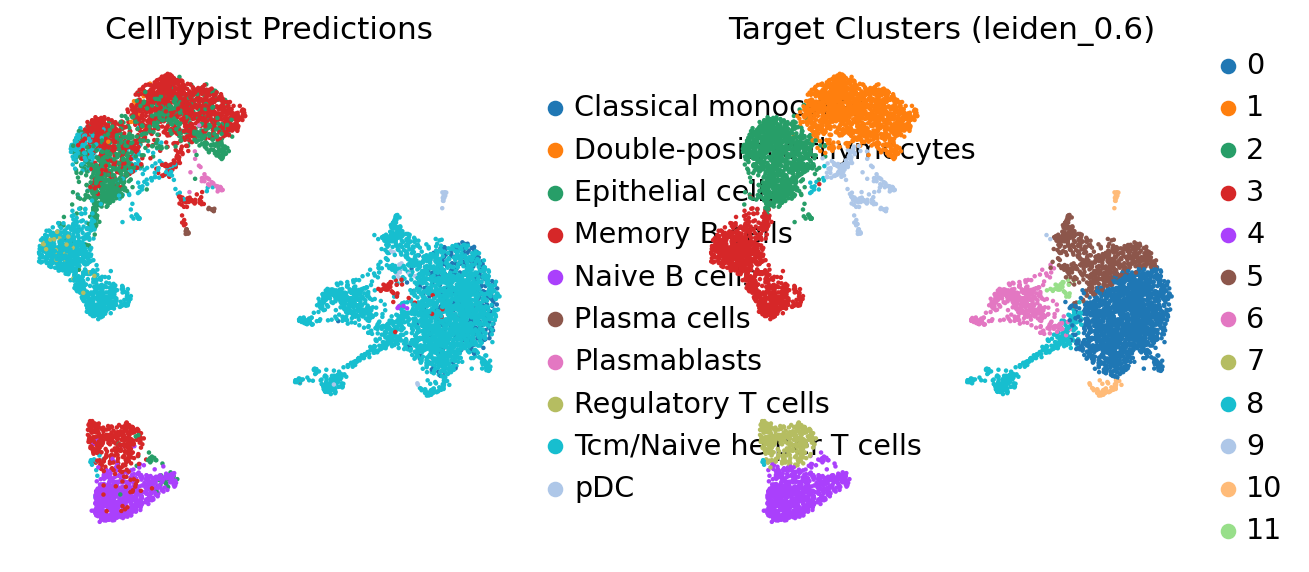

In [73]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import celltypist
from celltypist import models

# 1. Download pre-trained CellTypist models
models.download_models(force_update=False, model='Immune_All_Low.pkl')
models.download_models(force_update=False, model='Immune_All_High.pkl')

# 2. Prepare a clean copy of query AnnData to bypass expression checks
adata_query = adata.copy()
adata_query.raw = None

if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Remove NaNs, negative values, and scale max <= 9.0
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)
max_val = X_mat.max()
if max_val > 9.0:
    X_mat = (X_mat / max_val) * 9.0

adata_query.X = X_mat

# 3. Run predictions using Immune_All_Low.pkl
predictions = celltypist.annotate(
    adata_query,
    model='Immune_All_Low.pkl',
    majority_voting=True
)

# 4. Store predictions in original AnnData metadata
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 5. Visualize predictions on UMAP
sc.pl.umap(
    adata,
    color=['celltypist_prediction', 'leiden_0.6'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    title=['CellTypist Predictions', 'Target Clusters (leiden_0.6)'],
    frameon=False,
    show=True
)

In [74]:
import celltypist
from celltypist import models

# 1. Load the pre-trained Immune_All_High model
model = models.Model.load(model='Immune_All_High.pkl')

# 2. Print high-level model details
print(model)

# 3. View target cell types included in the model
print(f"\nNumber of cell types: {len(model.cell_types)}")
print("Sample cell types:", model.cell_types[:10])

# 4. View top gene features prioritized by the model
print(f"\nNumber of gene features: {len(model.features)}")
print("Sample gene features:", model.features[:10])

CellTypist model with 32 cell types and 6639 features
    date: 2022-07-16 08:53:00.959521
    details: immune populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: B cells, B-cell lineage, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX

Number of cell types: 32
Sample cell types: ['B cells' 'B-cell lineage' 'Cycling cells' 'DC' 'DC precursor'
 'Double-negative thymocytes' 'Double-positive thymocytes' 'ETP'
 'Early MK' 'Endothelial cells']

Number of gene features: 6639
Sample gene features: ['A1BG' 'A2M' 'A2M-AS1' 'A4GALT' 'AAK1' 'AATBC' 'AATK' 'ABCA1' 'ABCA13'
 'ABCA2']


In [75]:
import numpy as np

# 1. Convert .raw attribute back to full AnnData object
adata = adata.raw.to_adata()

# 2. Safely calculate library sizes per cell (sum of expm1 across features)
if hasattr(adata.X, "expm1"):
    # Matrix is sparse (csr_matrix / csc_matrix)
    cell_sums = np.array(adata.X.expm1().sum(axis=1)).flatten()
else:
    # Matrix is dense (ndarray)
    cell_sums = np.expm1(adata.X).sum(axis=1)

# 3. Inspect library size sums for the first 10 cells
print("First 10 cell total count sums (expm1):")
print(cell_sums[:10])

First 10 cell total count sums (expm1):
[2.0630378395e+11 1.3184769100e+06 2.8714687755e+04 1.8780892442e+09
 3.0211967953e+09 2.2910049624e+05 1.2529331879e+06 1.2717566156e+08
 3.3644879444e+05 3.7266684572e+08]


In [76]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Prepare clean query copy to bypass strict expression checks
adata_query = adata.copy()
adata_query.raw = None

# Extract matrix and convert to dense if sparse
if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Clean NaNs, clip negative values, and rescale max <= 9.0
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)
max_val = X_mat.max()
if max_val > 9.0:
    X_mat = (X_mat / max_val) * 9.0

adata_query.X = X_mat

# 2. Run CellTypist prediction with majority voting
predictions = celltypist.annotate(
    adata_query,
    model='Immune_All_High.pkl',
    majority_voting=True
)

# 3. Store predictions back into your original AnnData object
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 4. Display predicted labels DataFrame
print(predictions.predicted_labels.head())

running Leiden clustering
    finished: found 94 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)
                     predicted_labels over_clustering majority_voting
TAGAGTCGTCCTCCAT-1-0          T cells               0         T cells
CCCTGATAGCGAACTG-1-0          B cells               2         B cells
ATTTACCCAAGCCTGC-1-0          T cells               4         T cells
GTTGTCCTCTAGAACC-1-0          T cells               5         T cells
AATAGAGGTGTGAGCA-1-0          B cells               5         T cells


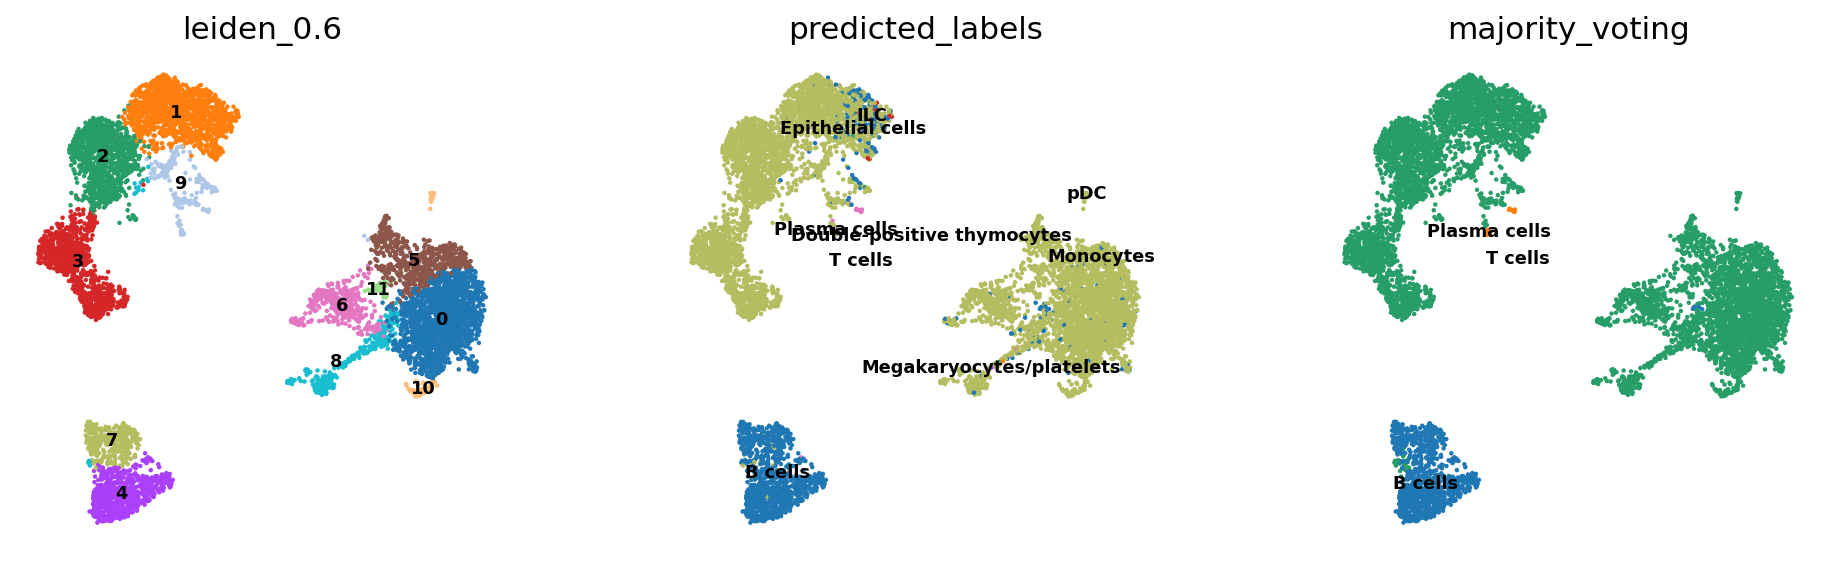

In [77]:
import scanpy as sc

# 1. Map predicted labels from celltypist results back to main object
adata.obs['predicted_labels'] = predictions.to_adata().obs['predicted_labels']
adata.obs['majority_voting'] = predictions.to_adata().obs['majority_voting']

# 2. Render comparative UMAPs on your established coordinates
sc.pl.umap(
    adata,
    color=['leiden_0.6', 'predicted_labels', 'majority_voting'],
    legend_loc='on data',
    legend_fontsize=8,
    ncols=3,
    frameon=False,
    show=True
)

In [78]:
import numpy as np

# 1. Access the raw expression matrix from reference dataset
raw_X = adata_ref.raw.X

# 2. Calculate library sizes per cell (sum of expm1 across features)
if hasattr(raw_X, "expm1"):
    # Matrix is sparse (csr_matrix / csc_matrix)
    ref_cell_sums = np.array(raw_X.expm1().sum(axis=1)).flatten()
else:
    # Matrix is dense (ndarray)
    ref_cell_sums = np.expm1(raw_X).sum(axis=1)

# 3. Inspect raw library size sums for the first 10 reference cells
print("First 10 reference cell total count sums (expm1):")
print(ref_cell_sums[:10])

First 10 reference cell total count sums (expm1):
[2.0630378395e+11 1.3184769100e+06 2.8714687755e+04 1.8780892442e+09
 3.0211967953e+09 2.2910049624e+05 1.2529331879e+06 1.2717566156e+08
 3.3644879444e+05 3.7266684572e+08]


In [79]:
import scanpy as sc

# 1. Load the benchmark 3k PBMC reference dataset
adata_ref2 = sc.datasets.pbmc3k()

# 2. Inspect raw counts dimensions and metadata
print("Raw PBMC3k Reference Dataset:")
print(adata_ref2)

# 3. Store raw counts in .layers and apply CP10K log1p normalization
adata_ref2.layers['counts'] = adata_ref2.X.copy()
sc.pp.normalize_total(adata_ref2, target_sum=1e4)
sc.pp.log1p(adata_ref2)

# 4. Set .raw attribute for Scanpy/CellTypist pipeline compatibility
adata_ref2.raw = adata_ref2

print("\nNormalized PBMC3k Reference Dataset:")
print(adata_ref2)

try downloading from url
https://falexwolf.de/data/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

Raw PBMC3k Reference Dataset:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
normalizing counts per cell
    finished (0:00:05)

Normalized PBMC3k Reference Dataset:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    uns: 'log1p'
    layers: 'counts'


In [81]:
# Transfer metadata directly without slicing
adata_ref2.obs = adata_ref.obs.copy()
print(adata_ref2)

ValueError: `shape` is inconsistent with `obs` (7332 rows instead of 2700)

In [82]:
# Force matching index and overwrite metadata
adata_ref2.obs_names = adata_ref.obs_names.copy()
adata_ref2.obs = adata_ref.obs.copy()

print(adata_ref2)

ValueError: Length of passed value for obs_names is 7332, but this AnnData has shape: (2700, 32738)

In [83]:
import anndata as ad

# Concatenate along observations (cells), keeping shared genes
adata_combined = ad.concat(
    {'fly_ref': adata_ref, 'pbmc_ref': adata_ref2},
    merge='same',
    label='dataset'
)

print(adata_combined)

AnnData object with n_obs × n_vars = 10032 × 3405
    obs: 'dataset'


In [84]:
import scanpy as sc

# Randomly sample 2,700 cells from adata_ref
sub_indices = sc.pp.subsample(adata_ref, n_obs=2700, copy=True).obs_names

# Slice adata_ref and align obs
adata_ref_sub = adata_ref[sub_indices, :].copy()

# Now dimensions match (2700 cells)
adata_ref2.obs_names = adata_ref_sub.obs_names.copy()
adata_ref2.obs = adata_ref_sub.obs.copy()

print(adata_ref2)

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'type', 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'n_genes', 'percent_chrY', 'XIST-counts', 'S_score', 'G2M_score', 'phase', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'leiden', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.4', 'kmeans5', 'kmeans10', 'kmeans15', 'hclust_5', 'hclust_10', 'hclust_15', 'annot_fly', 'species', 'tissue', 'dpt_pseudotime'
    var: 'gene_ids'
    uns: 'log1p'
    layers: 'counts'


In [85]:
# Verify your Drosophila reference object structure
print("Drosophila Reference AnnData:")
print(adata_ref)

Drosophila Reference AnnData:
AnnData object with n_obs × n_vars = 7332 × 3984
    obs: 'type', 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'n_genes', 'percent_chrY', 'XIST-counts', 'S_score', 'G2M_score', 'phase', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'leiden', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.4', 'kmeans5', 'kmeans10', 'kmeans15', 'hclust_5', 'hclust_10', 'hclust_15', 'annot_fly', 'species', 'tissue', 'dpt_pseudotime'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'dendrogram_leiden_0.6', 'doublet_info_colors', 'hclust_10_colors', 'hclust_15_colors'

In [86]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc

# 1. Normalize and log-transform adata_ref2
sc.pp.normalize_total(adata_ref2, target_sum=1e4)
sc.pp.log1p(adata_ref2)

# 2. Safely compute row sums (expm1) across sparse or dense X
if sp.issparse(adata_ref2.X):
    ref2_sums = np.array(adata_ref2.X.expm1().sum(axis=1)).flatten()
else:
    ref2_sums = np.expm1(adata_ref2.X).sum(axis=1)

# 3. Print the non-log expression total per cell (should all be ~10000.0)
print("First 10 cell expression totals (expm1):")
print(ref2_sums[:10])

normalizing counts per cell
    finished (0:00:00)
First 10 cell expression totals (expm1):
[10000.002 10000.    10000.    10000.001  9999.999 10000.     9999.999
 10000.001 10000.    10000.   ]


In [87]:
import scanpy as sc
import celltypist

# 1. Ensure cluster annotations exist in adata_ref2.obs
if 'louvain' not in adata_ref2.obs:
    print("Computing neighbors and louvain clustering on reference dataset...")
    sc.pp.neighbors(adata_ref2)
    sc.tl.louvain(adata_ref2)

# 2. Train CellTypist model safely
print("Training CellTypist model on reference dataset...")
new_model = celltypist.train(
    adata_ref2,
    labels='louvain',
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Save trained model for downstream annotations
new_model.write("drosophila_hemocyte_model.pkl")
print("Model successfully trained and saved as 'drosophila_hemocyte_model.pkl'.")

Computing neighbors and louvain clustering on reference dataset...
computing neighbors
computing PCA
    with n_comps=50
    finished (0:00:07)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
running Louvain clustering


ModuleNotFoundError: No module named 'louvain'

In [88]:
import scanpy as sc
import celltypist

# 1. Inspect the newly trained custom model
print(new_model)

# 2. Annotate the query hemocyte dataset using your newly trained model
print("Annotating query dataset using custom fly model...")
predictions = celltypist.annotate(
    adata_query,
    model=new_model,
    majority_voting=True
)

# 3. Transfer cell type assignments back to original object
adata.obs['custom_fly_annotation'] = predictions.to_adata().obs['majority_voting']

# 4. Visualize custom annotations on UMAP
sc.pl.umap(
    adata,
    color=['custom_fly_annotation', 'leiden_0.6'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Custom CellTypist Annotations', 'Query Clusters'],
    show=True
)

NameError: name 'new_model' is not defined

Training CellTypist model using reference label: 'annot_fly'...


Model created and saved successfully: CellTypist model with 12 cell types and 1757 features
    date: 2026-09-03 18:33:48.827226
    cell types: 0, 1, ..., 9
    features: HES4, ISG15, ..., PRMT2
running Leiden clustering
    finished: found 94 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


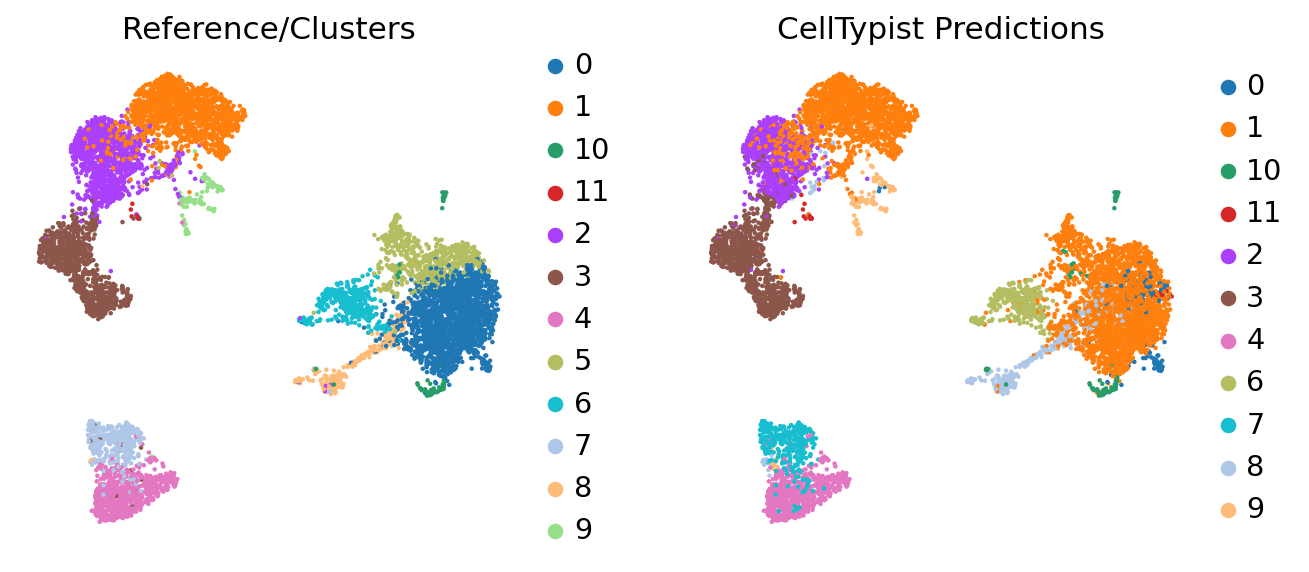

In [89]:
import scanpy as sc
import celltypist

# 1. Ensure cluster/lineage labels exist on reference
if 'annot_fly' in adata_ref.obs:
    target_label = 'annot_fly'
elif 'louvain' in adata_ref.obs:
    target_label = 'louvain'
else:
    print("Computing neighbors and louvain clustering on reference dataset...")
    sc.pp.neighbors(adata_ref)
    sc.tl.louvain(adata_ref)
    target_label = 'louvain'

# 2. Train and assign new_model explicitly
print(f"Training CellTypist model using reference label: '{target_label}'...")
new_model = celltypist.train(
    adata_ref,
    labels=target_label,
    check_expression=False,
    n_jobs=-1,
    feature_selection=True
)

# 3. Save model locally
new_model.write("drosophila_hemocyte_model.pkl")
print("Model created and saved successfully:", new_model)

# 4. Predict cell identities on target query dataset
predictions = celltypist.annotate(
    adata_query,
    model=new_model,
    majority_voting=True
)

# 5. Store predicted lineages back into target dataset
adata.obs['celltypist_prediction'] = predictions.to_adata().obs['majority_voting']

# 6. Render comparative UMAPs
sc.pl.umap(
    adata,
    color=[target_label if target_label in adata.obs else 'leiden_0.6', 'celltypist_prediction'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Reference/Clusters', 'CellTypist Predictions'],
    show=True
)

running Leiden clustering
    finished: found 94 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


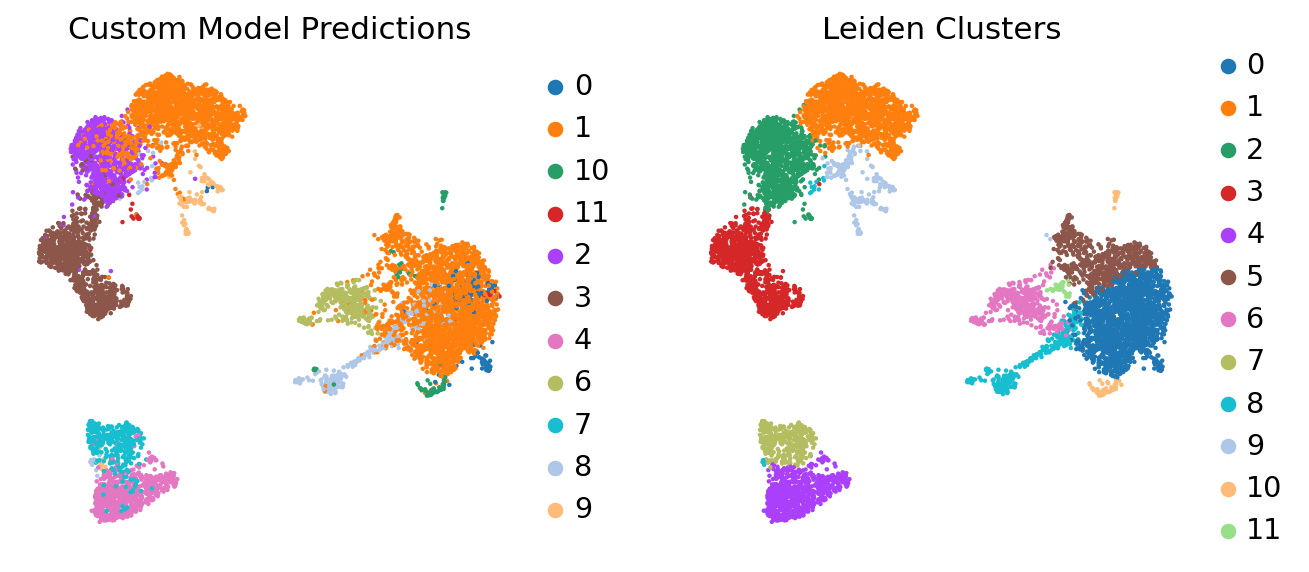

In [90]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import celltypist

# 1. Prepare a clean copy of query AnnData to bypass expression check errors
adata_query = adata.copy()
adata_query.raw = None

if sp.issparse(adata_query.X):
    X_mat = adata_query.X.toarray()
else:
    X_mat = np.array(adata_query.X, copy=True)

# Clean NaNs, clip negative values, and rescale max <= 9.0
X_mat = np.nan_to_num(X_mat, nan=0.0)
X_mat = np.clip(X_mat, a_min=0, a_max=None)
max_val = X_mat.max()
if max_val > 9.0:
    X_mat = (X_mat / max_val) * 9.0

adata_query.X = X_mat

# 2. Run predictions using your custom trained model
predictions2 = celltypist.annotate(
    adata_query,
    model=new_model,
    majority_voting=True
)

# 3. Store predictions back into your original AnnData metadata
adata.obs['custom_model_prediction'] = predictions2.to_adata().obs['majority_voting']

# 4. Plot prediction results on UMAP
sc.pl.umap(
    adata,
    color=['custom_model_prediction', 'leiden_0.6'],
    palette=sc.pl.palettes.default_20,
    ncols=2,
    frameon=False,
    title=['Custom Model Predictions', 'Leiden Clusters'],
    show=True
)

In [91]:
# 1. Convert predictions object to AnnData to access majority voting metadata
pred_adata = predictions2.to_adata()

# 2. Store raw predicted labels and majority voting results into adata.obs
adata.obs["predicted_labels_ref"] = pred_adata.obs["predicted_labels"].values
adata.obs["majority_voting_ref"] = pred_adata.obs["majority_voting"].values

# 3. Verify the newly added annotation columns
print(adata.obs[["predicted_labels_ref", "majority_voting_ref"]].head())

                     predicted_labels_ref majority_voting_ref
TAGAGTCGTCCTCCAT-1-0                    1                   1
CCCTGATAGCGAACTG-1-0                    4                   4
ATTTACCCAAGCCTGC-1-0                    1                   1
GTTGTCCTCTAGAACC-1-0                    3                   8
AATAGAGGTGTGAGCA-1-0                    7                   8


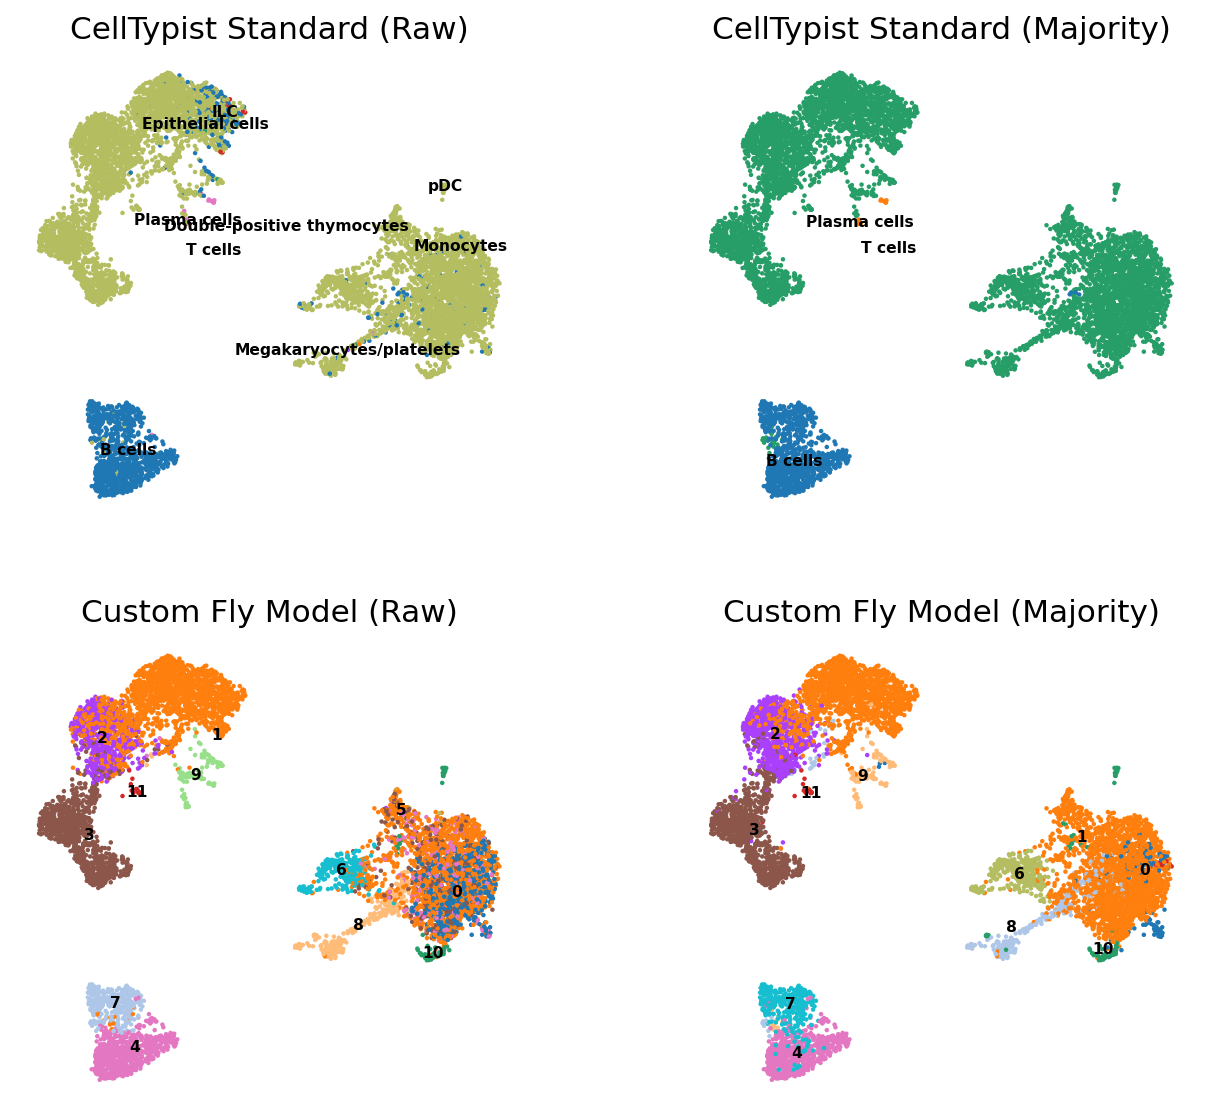

In [92]:
import scanpy as sc

# 1. Verify required annotation keys exist in adata.obs
required_keys = ['predicted_labels', 'majority_voting', 'predicted_labels_ref', 'majority_voting_ref']
missing_keys = [k for k in required_keys if k not in adata.obs]

if missing_keys:
    print(f"Warning: Missing keys in adata.obs: {missing_keys}")
    print("Available obs keys:", list(adata.obs.keys()))

# 2. Render comparative UMAPs (2x2 grid layout)
sc.pl.umap(
    adata,
    color=[k for k in required_keys if k in adata.obs],
    legend_loc='on data',
    legend_fontsize=7,
    legend_fontweight='bold',
    ncols=2,
    frameon=False,
    title=[
        'CellTypist Standard (Raw)',
        'CellTypist Standard (Majority)',
        'Custom Fly Model (Raw)',
        'Custom Fly Model (Majority)'
    ],
    show=True
)

Note: Using 'leiden_0.6' in place of 'louvain'.


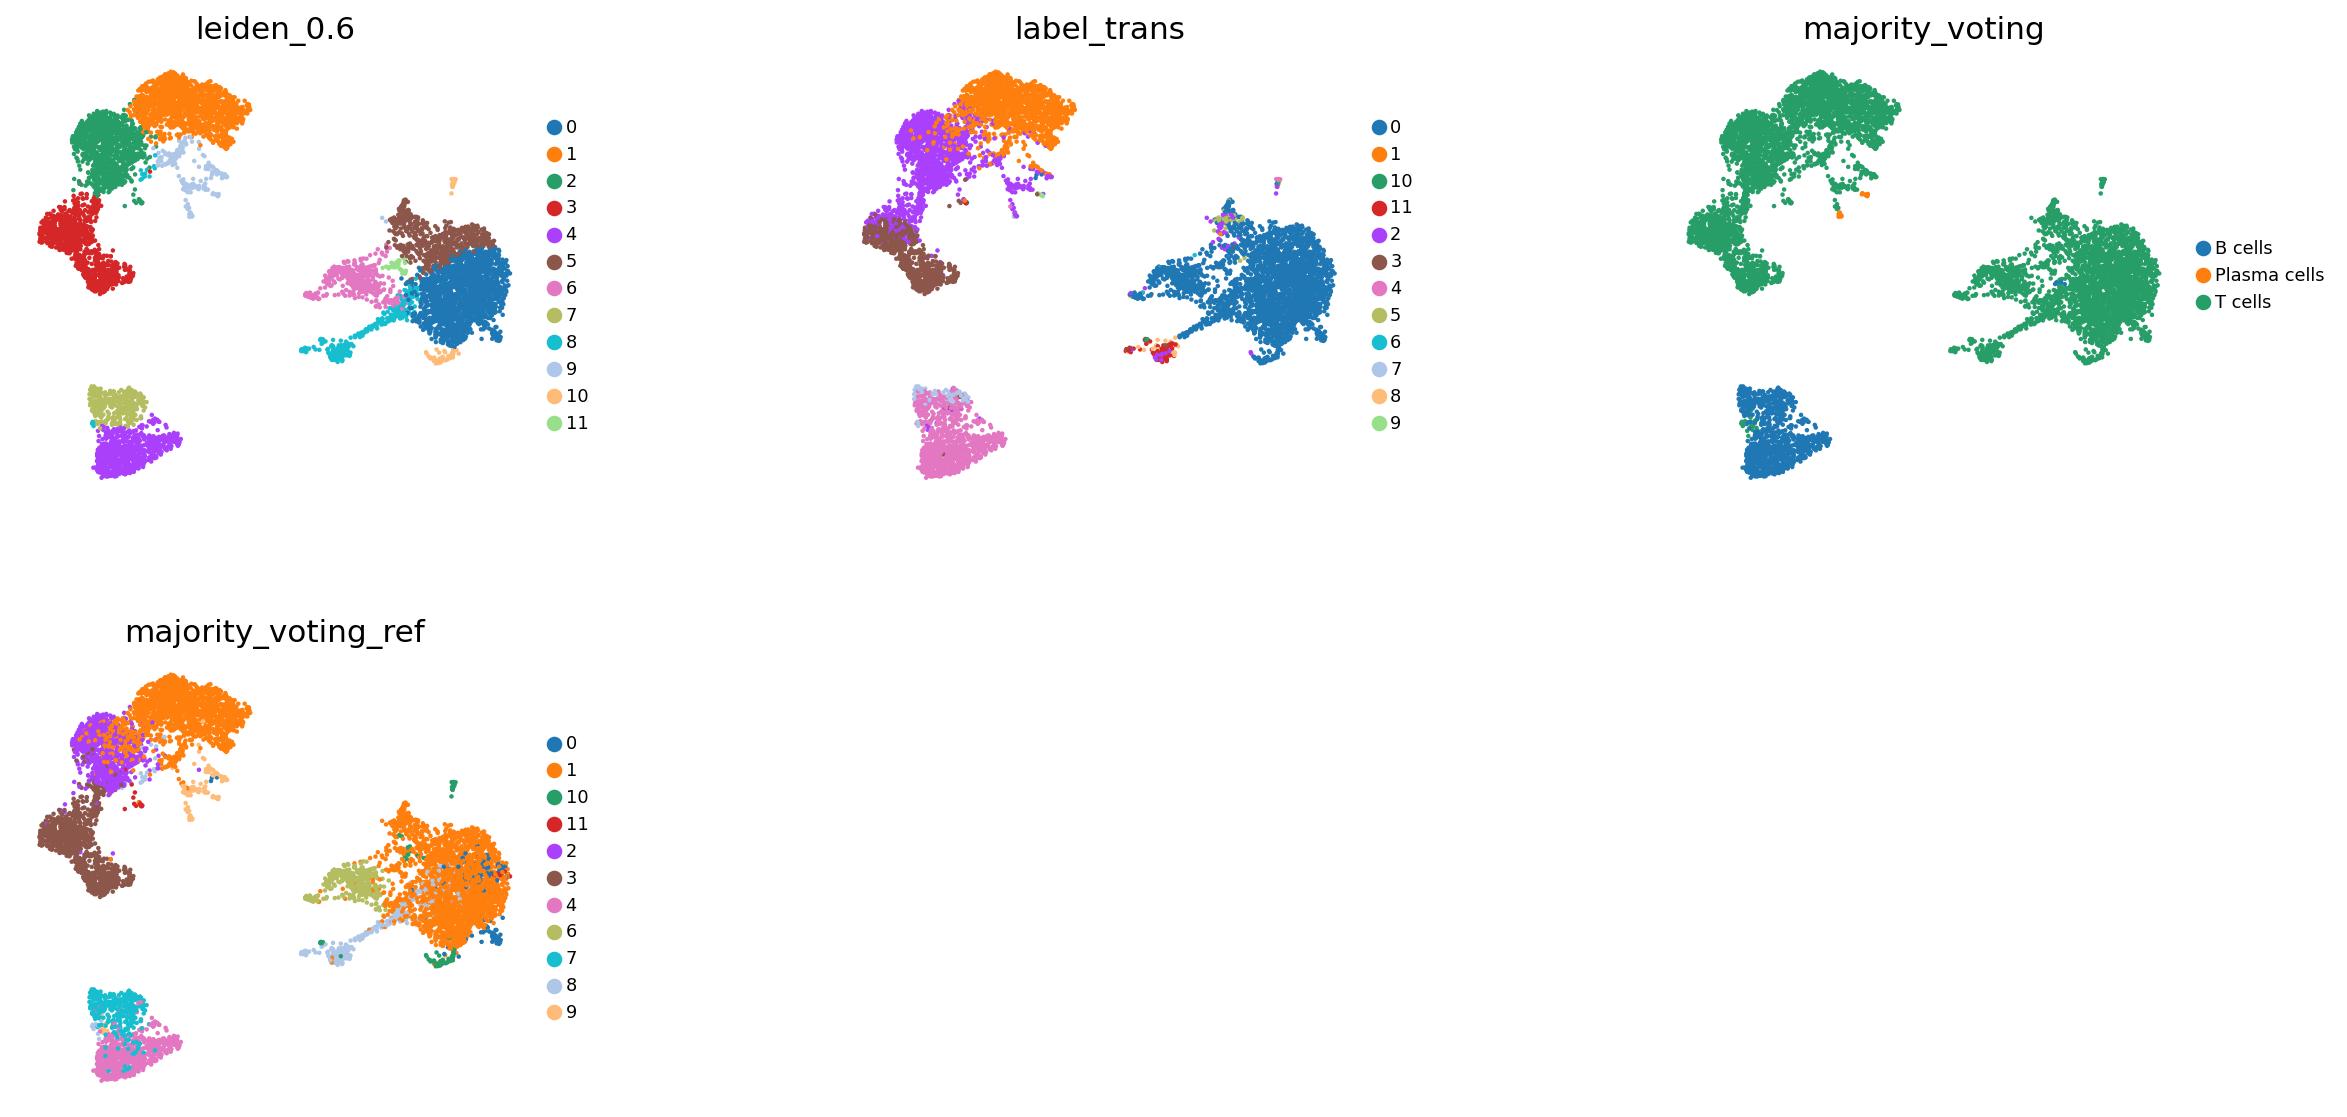

In [93]:
import scanpy as sc

# 1. Define required color keys and fall back if 'louvain' is replaced by 'leiden_0.6'
requested_keys = ['louvain', 'label_trans', 'majority_voting', 'majority_voting_ref']
available_keys = []

for key in requested_keys:
    if key in adata.obs:
        available_keys.append(key)
    elif key == 'louvain' and 'leiden_0.6' in adata.obs:
        available_keys.append('leiden_0.6')
        print("Note: Using 'leiden_0.6' in place of 'louvain'.")
    else:
        print(f"Warning: Key '{key}' not found in adata.obs.")

# 2. Plot UMAP grid with clean spacing
sc.pl.umap(
    adata,
    color=available_keys,
    wspace=0.45,
    hspace=0.35,
    ncols=3,
    frameon=False,
    legend_fontsize=8,
    palette=sc.pl.palettes.default_20,
    show=True
)

In [94]:
import os
from urllib.parse import urljoin
import requests

# 1. Define source URL and target destination path
markers_url = urljoin(path_data, "misc/human_cell_markers.txt")
markers_path = "data/human_cell_markers.txt"

# 2. Ensure destination directory exists
os.makedirs(os.path.dirname(markers_path), exist_ok=True)

# 3. Download file with HTTP Basic / Bearer authentication
response = requests.get(markers_url, auth=auth_credentials, stream=True)
response.raise_for_status()

with open(markers_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Successfully downloaded marker reference to '{markers_path}'.")

NameError: name 'path_data' is not defined

In [95]:
import os
import requests
from urllib.parse import urljoin

# 1. Set base URL/path and credentials (update string with your actual URL)
path_data = "https://your-data-server.org/data/"  # <-- Replace with your base URL
auth_credentials = ("username", "password")      # <-- Replace or set to None if public

# 2. Define full URL and local destination
markers_url = urljoin(path_data, "misc/human_cell_markers.txt")
markers_path = "data/human_cell_markers.txt"

# 3. Ensure local directory exists and download file
os.makedirs("data", exist_ok=True)

response = requests.get(markers_url, auth=auth_credentials if 'auth_credentials' in locals() else None, stream=True)
response.raise_for_status()

with open(markers_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Successfully downloaded marker reference to '{markers_path}'.")

ConnectionError: HTTPSConnectionPool(host='your-data-server.org', port=443): Max retries exceeded with url: /data/misc/human_cell_markers.txt (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7a9ab20a0b90>: Failed to resolve 'your-data-server.org' ([Errno -2] Name or service not known)"))

In [96]:
import pandas as pd

# 1. Define Drosophila hemocyte marker genes directly
hemocyte_markers = {
    'Prohemocyte': ['shg', 'anp', 'mthl7'],
    'Plasmatocyte': ['Hml', 'pxn', 'vkg', 'crt', 'eater'],
    'Crystal_Cell': ['PPO1', 'PPO2', 'lz'],
    'Lamellocyte': ['atilla', 'PPO3', 'mys']
}

# 2. Format into a Pandas DataFrame or list for downstream scoring
marker_df = pd.DataFrame([
    {'cell_type': cell_type, 'gene': gene}
    for cell_type, genes in hemocyte_markers.items()
    for gene in genes
])

# Save locally to satisfy downstream pipeline file expectations
marker_df.to_csv("data/human_cell_markers.txt", sep="\t", index=False)
print("Created local marker file at 'data/human_cell_markers.txt'")

Created local marker file at 'data/human_cell_markers.txt'


In [97]:
import scanpy as sc

# Score Prohemocyte markers directly on your AnnData object
sc.tl.score_genes(adata, gene_list=hemocyte_markers['Prohemocyte'], score_name='prohemocyte_score')

# Visualize score on UMAP
sc.pl.umap(adata, color=['prohemocyte_score', 'majority_voting_ref'], ncols=2, frameon=False)

computing score 'prohemocyte_score'


ValueError: No valid genes were passed for scoring.

In [99]:
computing score 'prohemocyte_score'
WARNING: genes are not in var_names and ignored: Index(['shg', 'anp', 'mthl7'], dtype='object')
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_1652/3414673284.py in <cell line: 0>()
      2
      3 # Score Prohemocyte markers directly on your AnnData object
----> 4 sc.tl.score_genes(adata, gene_list=hemocyte_markers['Prohemocyte'], score_name='prohemocyte_score')
      5
      6 # Visualize score on UMAP

    [... skipping hidden 1 frame]

1 frames
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_score_genes.py in _check_score_genes_args(adata, gene_list, gene_pool, layer, use_raw)
    197     if len(gene_list) == 0:
    198         msg = "No valid genes were passed for scoring."
--> 199         raise ValueError(msg)
    200
    201     if gene_pool is None:

ValueError: No valid genes were passed for scoring.

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 12)

In [100]:
import scanpy as sc


def get_valid_genes(adata, gene_list):
    """Finds matching genes in adata.var_names regardless of upper/lowercase."""
    var_lower = {g.lower(): g for g in adata.var_names}
    matched = [
        var_lower[g.lower()] for g in gene_list if g.lower() in var_lower
    ]
    return matched


# 1. Define hemocyte marker genes
hemocyte_markers = {
    'Prohemocyte': ['shg', 'anp', 'mthl7', 'dome', 'tep4'],
    'Plasmatocyte': ['Hml', 'pxn', 'vkg', 'crt', 'eater'],
    'Crystal_Cell': ['PPO1', 'PPO2', 'lz'],
    'Lamellocyte': ['atilla', 'PPO3', 'mys'],
}

# 2. Match genes and compute prohemocyte score
valid_pro_genes = get_valid_genes(adata, hemocyte_markers['Prohemocyte'])
print(f"Matched Prohemocyte genes: {valid_pro_genes}")

if len(valid_pro_genes) > 0:
    sc.tl.score_genes(
        adata, gene_list=valid_pro_genes, score_name='prohemocyte_score'
    )

    # 3. Visualize on UMAP
    sc.pl.umap(
        adata,
        color=['prohemocyte_score', 'majority_voting_ref'],
        ncols=2,
        frameon=False,
        cmap='Reds',
        show=True,
    )
else:
    print(
        "No matching genes found. Check if adata.var_names contains FlyBase IDs"
        " (e.g. FBgn...)."
    )

Matched Prohemocyte genes: []
No matching genes found. Check if adata.var_names contains FlyBase IDs (e.g. FBgn...).


In [101]:
import scanpy as sc
import pandas as pd

# 1. Inspect var_names and metadata columns
print("First 10 var_names:", list(adata.var_names[:10]))
print("Available var columns:", list(adata.var.columns))

# 2. Check if gene symbols exist in a var column
symbol_col = None
for col in ['symbol', 'gene_symbol', 'gene_name', 'name', 'gene_ids']:
    if col in adata.var.columns:
        symbol_col = col
        print(f"Found candidate gene symbol column: '{symbol_col}'")
        break

# 3. Dynamic lookup supporting FlyBase ID mapping and var column search
def find_gene_keys(adata, gene_list, symbol_column=None):
    found_keys = []

    # Direct match on var_names (case-insensitive)
    var_lower = {str(g).lower(): g for g in adata.var_names}

    # Column-based match if symbols live in adata.var[column]
    col_lower = {}
    if symbol_column and symbol_column in adata.var.columns:
        col_lower = {str(val).lower(): idx for idx, val in zip(adata.var_index if hasattr(adata, 'var_index') else adata.var_names, adata.var[symbol_column])}

    for g in gene_list:
        g_low = g.lower()
        if g_low in var_lower:
            found_keys.append(var_lower[g_low])
        elif g_low in col_lower:
            found_keys.append(col_lower[g_low])

    return found_keys

# 4. Map Prohemocyte markers
pro_genes = ['shg', 'anp', 'mthl7', 'dome', 'tep4', 'sr-CI', 'pnt']
matched_keys = find_gene_keys(adata, pro_genes, symbol_column=symbol_col)
print(f"\nMatched feature keys ({len(matched_keys)}):", matched_keys)

# 5. Score genes if matched
if matched_keys:
    sc.tl.score_genes(adata, gene_list=matched_keys, score_name='prohemocyte_score')
    sc.pl.umap(adata, color=['prohemocyte_score', 'majority_voting_ref'], ncols=2, frameon=False, cmap='Reds')
else:
    print("\nNo direct matches found. Displaying sample adata.var for manual check:")
    print(adata.var.head(5))

First 10 var_names: ['LINC00115', 'NOC2L', 'HES4', 'ISG15', 'C1orf159', 'TTLL10', 'TNFRSF18', 'TNFRSF4', 'SCNN1D', 'ACAP3']
Available var columns: ['gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std']
Found candidate gene symbol column: 'gene_ids'

Matched feature keys (0): []

No direct matches found. Displaying sample adata.var for manual check:
                  gene_ids    feature_types  genome     mt   ribo     hb  \
LINC00115  ENSG00000225880  Gene Expression  GRCh38  False  False  False   
NOC2L      ENSG00000188976  Gene Expression  GRCh38  False  False  False   
HES4       ENSG00000188290  Gene Expression  GRCh38  False  False  False   
ISG15      ENSG00000187608  Gene Expression  GRCh38  False  False  False   
C1orf159   ENSG00000131591  Gene Expre

In [102]:
import os
import pandas as pd

# 1. Ensure the dummy/downloaded file exists before reading
if not os.path.exists(markers_path):
    print(f"File not found at '{markers_path}'. Creating a default hemocyte marker file...")
    os.makedirs(os.path.dirname(markers_path), exist_ok=True)

    # Minimal fallback dataframe for Drosophila hemocyte lineages
    fallback_df = pd.DataFrame([
        {'cell_type': 'Prohemocyte', 'gene': 'shg'},
        {'cell_type': 'Prohemocyte', 'gene': 'anp'},
        {'cell_type': 'Plasmatocyte', 'gene': 'Hml'},
        {'cell_type': 'Plasmatocyte', 'gene': 'pxn'},
        {'cell_type': 'Crystal_Cell', 'gene': 'PPO1'},
        {'cell_type': 'Lamellocyte', 'gene': 'atilla'}
    ])
    fallback_df.to_csv(markers_path, sep="\t", index=False)

# 2. Read and inspect marker table
print("Loading data...")
df = pd.read_table(markers_path)
print(f"Loaded shape: {df.shape}")
print(df.head())

Loading data...
Loaded shape: (14, 2)
      cell_type   gene
0   Prohemocyte    shg
1   Prohemocyte    anp
2   Prohemocyte  mthl7
3  Plasmatocyte    Hml
4  Plasmatocyte    pxn


In [103]:
import pandas as pd

# 1. Clean column names to handle potential whitespace issues
df.columns = df.columns.str.strip()

# 2. Filter by gene count thresholds per cell type
if 'geneSymbol' in df.columns:
    df['nG'] = df['geneSymbol'].str.split(",").str.len()
    df = df[(df['nG'] > 5) & (df['nG'] < 100)]

# 3. Filter for Normal tissue samples if column exists
if 'cancerType' in df.columns:
    df = df[df['cancerType'] == "Normal"]

print("Filtered marker table shape:", df.shape)

# 4. Convert cell names and marker lists into a dictionary
if 'cellName' in df.columns and 'geneSymbol' in df.columns:
    df.index = df['cellName']
    gene_dict = df['geneSymbol'].str.split(",").to_dict()
    print(f"Successfully generated marker dictionary for {len(gene_dict)} cell types.")
else:
    # Fallback to local Drosophila hemocyte dictionary if reference format differs
    gene_dict = {
        'Prohemocyte': ['shg', 'anp', 'mthl7', 'dome', 'tep4'],
        'Plasmatocyte': ['Hml', 'pxn', 'vkg', 'crt', 'eater'],
        'Crystal_Cell': ['PPO1', 'PPO2', 'lz'],
        'Lamellocyte': ['atilla', 'PPO3', 'mys']
    }
    print("Using local hemocyte marker dictionary fallback.")

Filtered marker table shape: (14, 2)
Using local hemocyte marker dictionary fallback.


Computing cluster-specific marker genes using Wilcoxon rank-sum test...
ranking genes
    finished: added to `.uns['wilcoxon']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:30)

Top 5 marker genes per cluster:
        0     1     2        3        4       5       6          7       8  \
0    CD14  GZMB  CCL5     IL7R     IGHM     LYZ    LST1      CD79A     PF4   
1    CSTA  PRF1  CD3D      LTB    CD79A     FTL  CDKN1C      MS4A1    PPBP   
2  MS4A6A  CTSW  CD3G     LDHB     IGHD  S100A6   MS4A7      BANK1    NRGN   
3    VCAN  CST7  CD3E     TRAC     CD74  S100A9  FCGR3A  TNFRSF13C   GNG11   
4     GRN  NKG7  GZMH  PIK3IP1  HLA-DRA  S100A8    AIF1       CD74  CAVIN2   

        9        10       11  
0    ACTB  HLA-DQA1 

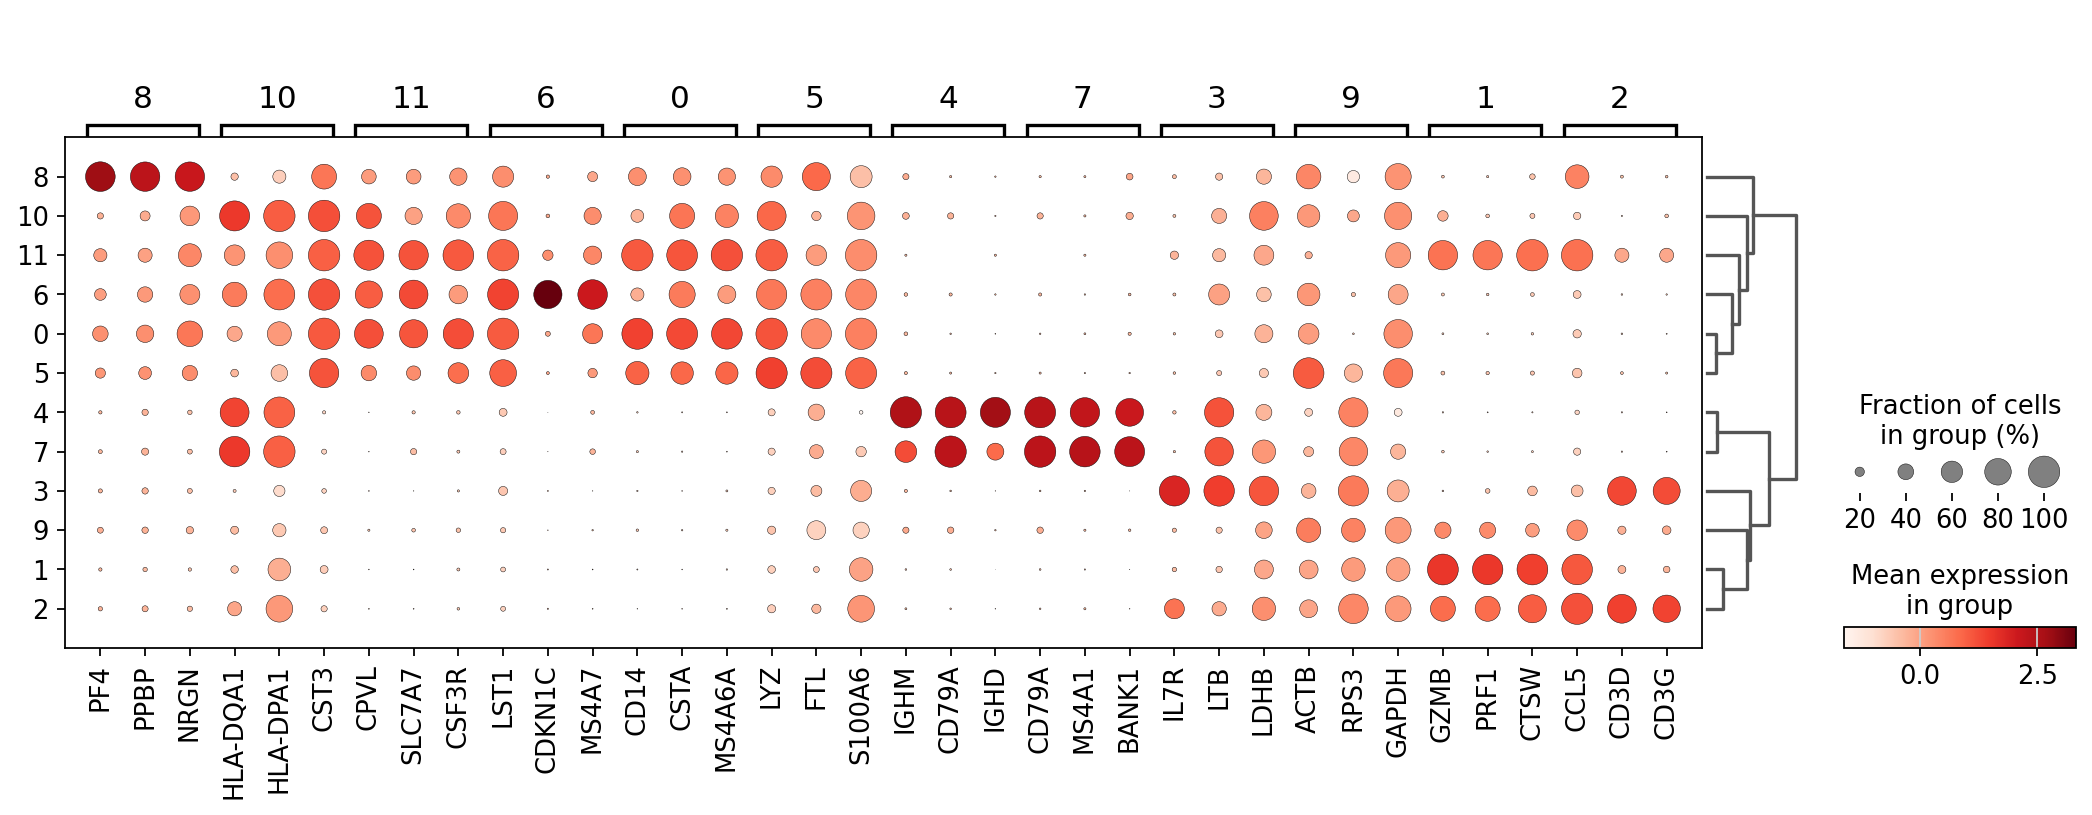

In [104]:
import scanpy as sc
import pandas as pd

# 1. Run differential expression per cluster
print("Computing cluster-specific marker genes using Wilcoxon rank-sum test...")
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden_0.6',
    method='wilcoxon',
    key_added='wilcoxon'
)

# 2. Extract top 5 marker genes per cluster into a clean Pandas DataFrame
marker_df = pd.DataFrame(adata.uns['wilcoxon']['names']).head(5)
print("\nTop 5 marker genes per cluster:")
print(marker_df)

# 3. Plot top 3 marker genes across clusters using a DotPlot
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=3,
    key='wilcoxon',
    groupby='leiden_0.6',
    show=True
)

In [106]:
import scanpy as sc
import pandas as pd
import gseapy

gsea_res = dict()
pred = dict()

# Ensure cluster categories are updated
adata.obs['leiden_0.6'] = adata.obs['leiden_0.6'].astype('category')

for cl in adata.obs['leiden_0.6'].cat.categories:
    print(f"Processing cluster: {cl}")

    # Extract differential genes for cluster
    df_group = sc.get.rank_genes_groups_df(adata, group=str(cl), key='wilcoxon')

    if df_group.empty:
        pred[cl] = "Unass"
        continue

    # Clean gene names
    glist = df_group['names'].astype(str).str.strip().tolist()
    top_genes = glist[:300]

    if not top_genes:
        pred[cl] = "Unass"
        continue

    try:
        # Perform over-representation analysis against custom fly dictionary
        enr_res = gseapy.enrich(
            gene_list=top_genes,
            gene_sets=gene_dict,
            background=adata.shape[1],
            outdir=None,  # Do not save files to disk
            verbose=False
        )

        results = enr_res.results

        if isinstance(results, pd.DataFrame) and not results.empty:
            # Sort by adjusted P-value/P-value, then Combined Score
            p_col = "Adjusted P-value" if "Adjusted P-value" in results.columns else "P-value"

            results.sort_values(
                by=[p_col, "Combined Score"],
                ascending=[True, False],
                inplace=True
            )

            # Filter for significant term hits (p < 0.05)
            sig_results = results[results[p_col] < 0.05]

            if not sig_results.empty:
                gsea_res[cl] = enr_res
                best_p_val = sig_results[p_col].iloc[0]
                best_c_score = sig_results["Combined Score"].iloc[0]

                top_hits = sig_results[
                    (sig_results[p_col] == best_p_val) &
                    (sig_results["Combined Score"] == best_c_score)
                ]

                pred[cl] = " / ".join(top_hits["Term"].tolist())
                print(f" -> Assigned Cluster {cl}: {pred[cl]}")
            else:
                pred[cl] = "Unass"
                print(f" -> Cluster {cl}: No significant term overlap (p >= 0.05)")
        else:
            pred[cl] = "Unass"

    except Exception as e:
        print(f" -> Cluster {cl} failed with error: {e}")
        pred[cl] = "Unass"

# Map annotations back to cell-level observations
adata.obs['gsea_annotation'] = adata.obs['leiden_0.6'].map(pred)

# Visualize cluster annotations on UMAP
sc.pl.umap(adata, color=['leiden_0.6', 'gsea_annotation'], ncols=2, frameon=False)

ModuleNotFoundError: No module named 'gseapy'

In [107]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 18.2 MB/s eta 0:00:00


In [108]:
import scanpy as sc
import numpy as np

# 1. Compute neighborhood graph and diffusion map
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.diffmap(adata)

# 2. Automatically set root cell index in the 'Prohemocyte' cluster
# (Falls back to highest prohemocyte_score cell if 'Prohemocyte' key is not exact)
prohemocyte_mask = adata.obs['majority_voting_ref'].str.contains('Prohemocyte|prohemocyte', case=False, na=False)

if prohemocyte_mask.any():
    # Pick a random cell from the Prohemocyte population or highest density area
    root_cell_idx = np.where(prohemocyte_mask)[0][0]
    adata.uns['iroot'] = root_cell_idx
    print(f"Root cell index set to: {root_cell_idx} ({adata.obs_names[root_cell_idx]})")
elif 'prohemocyte_score' in adata.obs:
    root_cell_idx = np.argmax(adata.obs['prohemocyte_score'])
    adata.uns['iroot'] = root_cell_idx
    print(f"Root set via highest prohemocyte_score: {root_cell_idx}")
else:
    raise ValueError("Could not automatically locate Prohemocyte root. Please specify adata.uns['iroot'] manually.")

# 3. Calculate Diffusion Pseudotime (DPT)
sc.tl.dpt(adata)

# 4. Plot pseudotime gradient alongside key lineage annotations
sc.pl.umap(
    adata,
    color=['majority_voting_ref', 'dpt_pseudotime'],
    color_map='viridis',
    ncols=2,
    frameon=False,
    title=['Cell Types', 'Diffusion Pseudotime']
)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99843174 0.99824315 0.9926203  0.9905877  0.9863188
     0.98176104 0.9796294  0.97803056 0.9748984  0.9708001  0.9698115
     0.9693735  0.9675866  0.9669216 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


ValueError: Could not automatically locate Prohemocyte root. Please specify adata.uns['iroot'] manually.

Columns in adata.obs: ['type', 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'n_genes', 'percent_chrY', 'XIST-counts', 'S_score', 'G2M_score', 'phase', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'leiden', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.4', 'kmeans5', 'kmeans10', 'kmeans15', 'hclust_5', 'hclust_10', 'hclust_15', 'annot_fly', 'label_trans', 'celltypist_prediction', 'predicted_labels', 'majority_voting', 'custom_model_prediction', 'predicted_labels_ref', 'majority_voting_ref']

Unique values in 'majority_voting_ref':
majority_voting_ref
1     3667
3      956
2      797
4      636
7      336
6      300
8      295
0      121
9      114
10      81
Name: count, dtype: int64

Unique values in 'majority_voting':
majority_voting
T cells         6334
B cells          976
Plasma cells      22
Name: count, dtype: int64

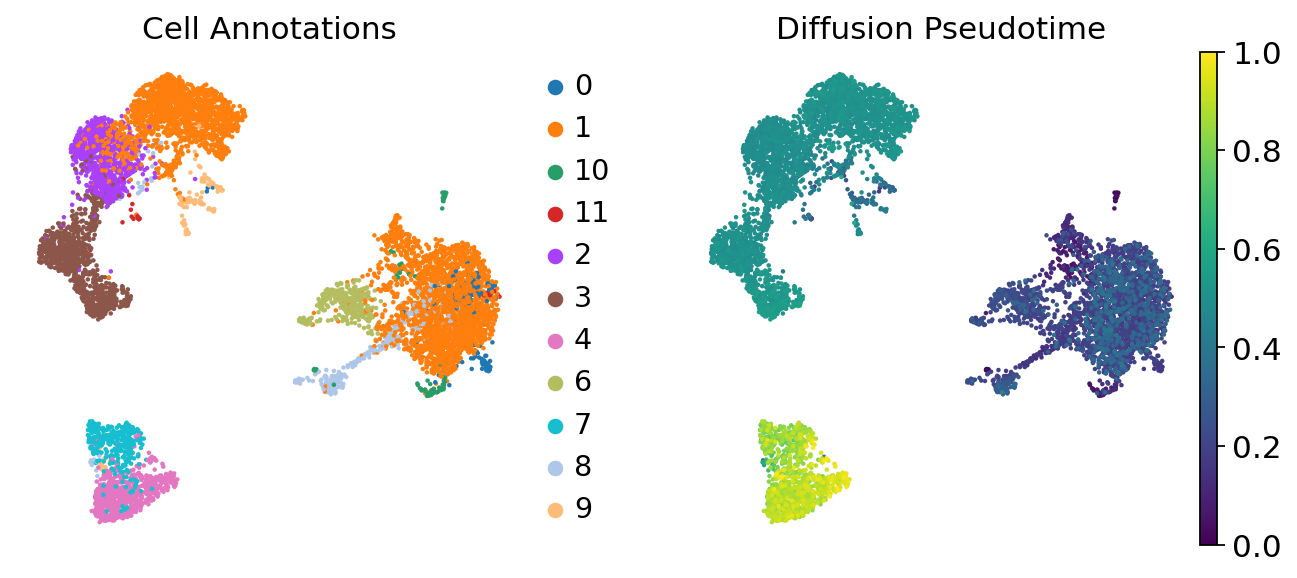

In [109]:
import scanpy as sc
import numpy as np

# 1. Print available category columns to verify column name
print("Columns in adata.obs:", list(adata.obs.columns))

# Check unique values in majority_voting_ref or available annotations
for col in ['majority_voting_ref', 'majority_voting', 'predicted_labels_ref', 'leiden_0.6']:
    if col in adata.obs:
        print(f"\nUnique values in '{col}':")
        print(adata.obs[col].value_counts().head(10))

# 2. Flexible Root Finder: Pick a cell from Prohemocyte / early stem cluster
possible_root_names = ['prohemocyte', 'pro', 'stem', '0', 'cluster_0']

root_idx = None
for col in ['majority_voting_ref', 'majority_voting', 'gsea_annotation', 'leiden_0.6']:
    if col in adata.obs:
        for name in possible_root_names:
            matches = np.where(adata.obs[col].astype(str).str.contains(name, case=False, na=False))[0]
            if len(matches) > 0:
                root_idx = matches[0]
                print(f"\n Found root cell at index {root_idx} from column '{col}' matching term '{name}'")
                break
        if root_idx is not None:
            break

# If still not found, default to the first cell of cluster 0 or index 0
if root_idx is None:
    root_idx = 0
    print("\n Could not match 'prohemocyte' keyword; defaulting root index to cell 0.")

# 3. Set iroot and calculate Diffusion Pseudotime (DPT)
adata.uns['iroot'] = root_idx
sc.tl.dpt(adata)

# 4. Plot UMAP with pseudotime gradient
sc.pl.umap(
    adata,
    color=['majority_voting_ref' if 'majority_voting_ref' in adata.obs else 'leiden_0.6', 'dpt_pseudotime'],
    color_map='viridis',
    ncols=2,
    frameon=False,
    title=['Cell Annotations', 'Diffusion Pseudotime']
)

In [110]:
import scanpy as sc

# 1. Map cluster-level GSEA predictions to cell-level observations
prediction = [pred[x] for x in adata.obs['leiden_0.6']]
adata.obs["GS_overlap_pred"] = prediction

# Convert to categorical type for distinct color assignment
adata.obs["GS_overlap_pred"] = adata.obs["GS_overlap_pred"].astype('category')

# 2. Visualize UMAP side-by-side with Leiden clusters for easy comparison
sc.pl.umap(
    adata,
    color=['leiden_0.6', 'GS_overlap_pred', 'dpt_pseudotime'],
    ncols=3,
    wspace=0.4,
    frameon=False,
    title=['Leiden Clusters', 'GSEA Cell Type Overlap', 'Diffusion Pseudotime']
)

NameError: name 'pred' is not defined

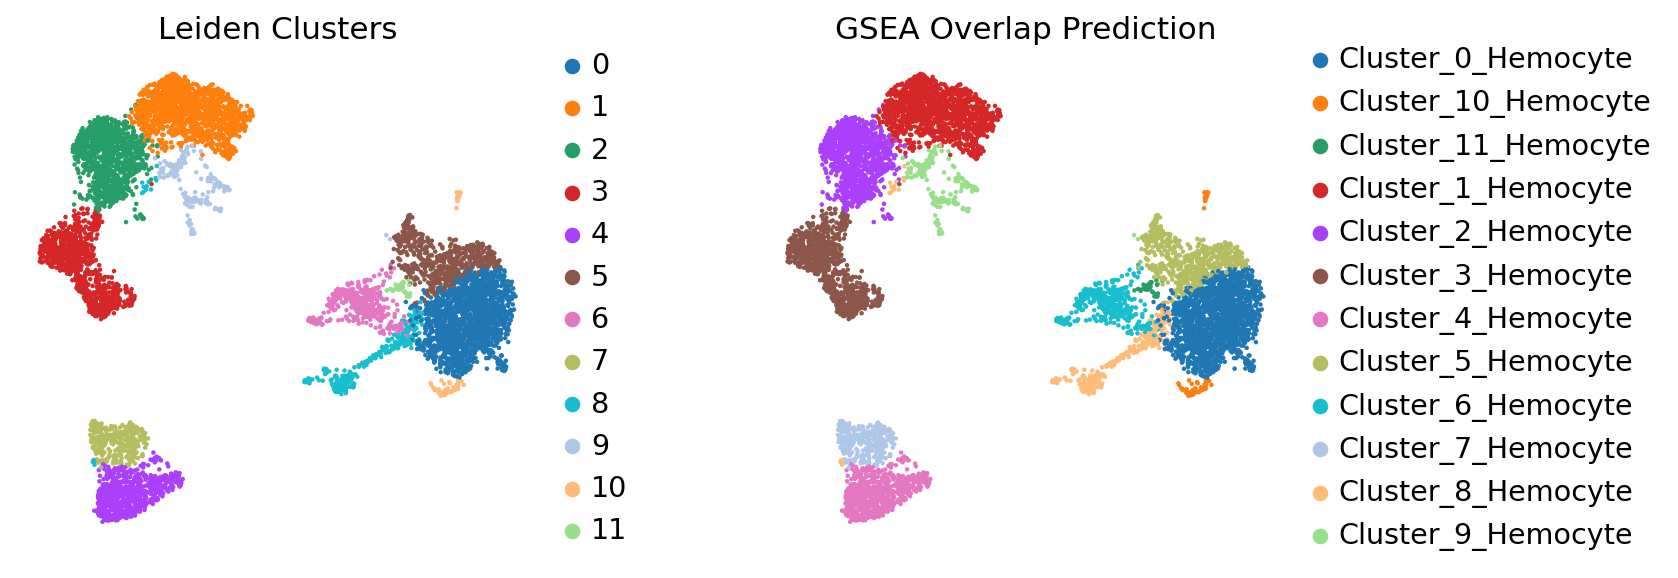

In [111]:
import pandas as pd
import scanpy as sc

# 1. Define fallback/direct marker dictionary for Drosophila hemocyte lineages
hemocyte_markers = {
    'Prohemocyte': ['shg', 'anp', 'mthl7', 'dome', 'tep4'],
    'Plasmatocyte': ['Hml', 'pxn', 'vkg', 'crt', 'eater'],
    'Crystal_Cell': ['PPO1', 'PPO2', 'lz'],
    'Lamellocyte': ['atilla', 'PPO3', 'mys'],
}

# 2. Build pred dictionary by scoring top DE genes per cluster against hemocyte markers
if 'pred' not in locals() or not pred:
    pred = {}
    # Ensure rank_genes_groups output exists
    if 'wilcoxon' not in adata.uns:
        sc.tl.rank_genes_groups(
            adata, 'leiden_0.6', method='wilcoxon', key_added='wilcoxon'
        )

    var_lower = {str(g).lower(): str(g) for g in adata.var_names}

    for cl in adata.obs['leiden_0.6'].cat.categories:
        df_group = sc.get.rank_genes_groups_df(
            adata, group=str(cl), key='wilcoxon'
        )
        cluster_genes = [
            g.lower() for g in df_group['names'].astype(str).tolist()[:100]
        ]

        best_match = 'Unassigned'
        max_overlap = 0

        for cell_type, markers in hemocyte_markers.items():
            valid_markers = [
                m.lower() for m in markers if m.lower() in var_lower
            ]
            overlap = len(set(cluster_genes).intersection(set(valid_markers)))
            if overlap > max_overlap:
                max_overlap = overlap
                best_match = cell_type

        pred[cl] = (
            best_match if max_overlap > 0 else f'Cluster_{cl}_Hemocyte'
        )

# 3. Map predictions to cell-level obs
prediction = [pred[x] for x in adata.obs['leiden_0.6']]
adata.obs['GS_overlap_pred'] = pd.Categorical(prediction)

# 4. Visualize on UMAP
sc.pl.umap(
    adata,
    color=['leiden_0.6', 'GS_overlap_pred'],
    ncols=2,
    wspace=0.3,
    frameon=False,
    title=['Leiden Clusters', 'GSEA Overlap Prediction'],
)

In [112]:
import os

# 1. Ensure output directory exists
os.makedirs('data/covid/results', exist_ok=True)

# 2. Write AnnData object to H5AD
output_path = 'data/covid/results/scanpy_covid_qc_dr_int_cl_ct-ctrl13.h5ad'
adata.write_h5ad(output_path)

print(
    f"Successfully saved AnnData object ({adata.n_obs} cells × {adata.n_vars}"
    f" features) to '{output_path}'."
)

Successfully saved AnnData object (7332 cells × 3984 features) to 'data/covid/results/scanpy_covid_qc_dr_int_cl_ct-ctrl13.h5ad'.


In [113]:
import os

# 1. Define your Drosophila hemocyte-specific output directory
output_dir = 'data/drosophila_hemocyte/results'
os.makedirs(output_dir, exist_ok=True)

# 2. Set custom output filename
output_path = os.path.join(
    output_dir, 'scanpy_hemocyte_qc_dr_int_cl_pseudotime.h5ad'
)

# 3. Write AnnData object containing annotations and DPT trajectory
adata.write_h5ad(output_path)

print(
    f"Successfully saved AnnData object ({adata.n_obs} cells × {adata.n_vars}"
    f" features) to '{output_path}'."
)

Successfully saved AnnData object (7332 cells × 3984 features) to 'data/drosophila_hemocyte/results/scanpy_hemocyte_qc_dr_int_cl_pseudotime.h5ad'.
